# State Level Models — Data Preparation, SARIMAX and XGBoost

This notebook implements the state-level modeling pipeline described in Plan A, extending the national model to a pooled panel of 50 US states.

1. **Data merging** — load and join all source files at the state × month level
2. **Industry group assignment** — fixed state labels from pre-specified industry classification
3. **SARIMAX** — pooled panel SARIMAX with industry group dummies and interaction terms; common ARIMA order carried forward from the national model
4. **XGBoost** — pooled panel gradient boosting with industry group passed as a categorical feature; SHAP-based interpretation of the industry and unemployment interaction effects

**Panel coverage:** 50 states × 113 months = 5,650 state-month observations, spanning **2016-07 to 2025-12**.

**Data decisions carried forward from national model:**
- Lock-in premium $L_t$: constructed as `mortgage30us_avg` − `treasury_10y` (national series, uniform across states)
- Unemployment $U_{it}$: state-level monthly unadjusted rate in levels (confirmed stationary in national model)
- HPI $H_{it}$: state quarterly FHFA HPI (`index_nsa`) expanded to monthly via **step interpolation** (quarterly value repeated across the 3 months of each quarter); entered as **centered levels** $\tilde{H}_{it} = H_{it} - \bar{H}_i$ in both SARIMAX and XGBoost — not differenced, since $\Delta H_{it}$ is zero for 2 out of every 3 months and produces a structurally broken differenced series
- Permits $S_{it}$: `units_total_thousand` is the permit count in thousand (the same scale as the national model); entered as first difference $\Delta S_{it}$
- Listing data extends to 2026-02 but is **clipped to 2025-12** to match the permits series endpoint; DC is **excluded** from the panel

**Industry group treatment by model:**
- **SARIMAX**: industry groups encoded as dummy variables $D_{ki}$ (one-hot, reference group omitted) — required because SARIMAX is a linear model that cannot discover group-level effects without explicit indicators
- **XGBoost**: industry group passed as a **pandas Categorical** feature directly — XGBoost discovers group-level effects and interactions through tree splits without needing manual dummy encoding


## Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

import xgboost as xgb
import shap

print("All imports successful.")
print(f"pandas  : {pd.__version__}")
print(f"xgboost : {xgb.__version__}")
print(f"shap    : {shap.__version__}")

All imports successful.
pandas  : 2.0.3
xgboost : 3.2.0
shap    : 0.48.0


f:\Miniconda3\envs\pydata\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Industry Group Assignment

Each state is assigned a fixed industry group label based on dominant industry composition, pre-determined before the study period to avoid endogeneity. Groups are limited to 6 categories to preserve degrees of freedom and maintain interpretability.

| Group | States |
|---|---|
| Construction & Development | AZ, LA, TX, UT |
| Energy/Resource-based Industries | AK, AR, ID, MS, MT, NE, NM, ND, OK, OR, SD, VT, WV, WY |
| Finance & Corporate Services | CT, DE, MN, NJ, NY, NC, PA, RI |
| Manufacturing and Industrial Production | AL, IL, IN, IA, KS, KY, MI, MO, NH, OH, SC, TN, WI |
| Tech/Knowledge and Innovation Industries | CA, CO, GA, MD, MA, VA, WA |
| Leisure & Hospitality | FL, HI, ME, NV |

**Reference group** (absorbed into the intercept / state fixed effects): `Energy/Resource-based Industries` — chosen as the smallest group, so all $\lambda_k$ coefficients represent deviations from this baseline.


In [2]:
INDUSTRY_GROUPS = {
    "AZ": "Construction & Development",
    "LA": "Construction & Development",
    "TX": "Construction & Development",
    "UT": "Construction & Development",

    "AK": "Energy/Resource-based",
    "AR": "Energy/Resource-based",
    "ID": "Energy/Resource-based",
    "MS": "Energy/Resource-based",
    "MT": "Energy/Resource-based",
    "NE": "Energy/Resource-based",
    "NM": "Energy/Resource-based",
    "ND": "Energy/Resource-based",
    "OK": "Energy/Resource-based",
    "OR": "Energy/Resource-based",
    "SD": "Energy/Resource-based",
    "VT": "Energy/Resource-based",
    "WV": "Energy/Resource-based",
    "WY": "Energy/Resource-based",

    "CT": "Finance & Corporate Services",
    "DE": "Finance & Corporate Services",
    "MN": "Finance & Corporate Services",
    "NJ": "Finance & Corporate Services",
    "NY": "Finance & Corporate Services",
    "NC": "Finance & Corporate Services",
    "PA": "Finance & Corporate Services",
    "RI": "Finance & Corporate Services",

    "AL": "Manufacturing & Industrial",
    "IL": "Manufacturing & Industrial",
    "IN": "Manufacturing & Industrial",
    "IA": "Manufacturing & Industrial",
    "KS": "Manufacturing & Industrial",
    "KY": "Manufacturing & Industrial",
    "MI": "Manufacturing & Industrial",
    "MO": "Manufacturing & Industrial",
    "NH": "Manufacturing & Industrial",
    "OH": "Manufacturing & Industrial",
    "SC": "Manufacturing & Industrial",
    "TN": "Manufacturing & Industrial",
    "WI": "Manufacturing & Industrial",

    "CA": "Tech/Knowledge & Innovation",
    "CO": "Tech/Knowledge & Innovation",
    "GA": "Tech/Knowledge & Innovation",
    "MD": "Tech/Knowledge & Innovation",
    "MA": "Tech/Knowledge & Innovation",
    "VA": "Tech/Knowledge & Innovation",
    "WA": "Tech/Knowledge & Innovation",

    "FL": "Leisure & Hospitality",
    "HI": "Leisure & Hospitality",
    "ME": "Leisure & Hospitality",
    "NV": "Leisure & Hospitality",
}

# Reference group (omitted category)
REFERENCE_GROUP = "Energy/Resource-based"

# Ordered list of non-reference groups (for dummy columns)
NON_REF_GROUPS = [
    "Construction & Development",
    "Finance & Corporate Services",
    "Manufacturing & Industrial",
    "Tech/Knowledge & Innovation",
    "Leisure & Hospitality",
]

group_counts = pd.Series(INDUSTRY_GROUPS).value_counts()
print("Industry group sizes:")
print(group_counts.to_string())
print(f"\nTotal states assigned : {len(INDUSTRY_GROUPS)}")
print(f"Reference group       : {REFERENCE_GROUP}")

Industry group sizes:
Energy/Resource-based           14
Manufacturing & Industrial      13
Finance & Corporate Services     8
Tech/Knowledge & Innovation      7
Construction & Development       4
Leisure & Hospitality            4

Total states assigned : 50
Reference group       : Energy/Resource-based


## Load and Merge Datasets

All six source files are loaded and merged into a balanced panel at the state × month level.

**Key decisions:**
- DC excluded from the panel
- Listing data clipped at **2025-12** to match the permits series endpoint (raw listing file extends to 2026-02)
- HPI is quarterly; expanded to monthly via **step interpolation** (quarterly value repeated for each of the 3 months in that quarter)
- HPI enters both models as **centered levels** $\tilde{H}_{it} = H_{it} - \bar{H}_i$ — not differenced — because $\Delta H_{it}$ from step-interpolated data is zero for 2 out of every 3 months, producing a structurally broken series; centering on the state mean means the state fixed effects / industry dummies absorb the baseline level and within-state quarterly variation provides the identifying signal
- Permits `units_total_thousand` as permit count in thousand, matching the scale of the national model
- Lock-in premium $L_t$ = `mortgage30us_avg` − `treasury_10y` is national and identical for all states in each period


In [3]:
# ── File paths ─────────────────────────────────────────────────────────────
PATH_TREASURY  = "../../data/national/national_10y_treasury_monthly.csv"
PATH_MORTGAGE  = "../../data/national/national_30y_mortgage_monthly.csv"
PATH_HPI       = "../../data/states/state_house_price_index_quarterly.csv"
PATH_LISTING   = "../../data/states/state_new_listing_count_monthly.csv"
PATH_PERMITS   = "../../data/states/states_permits_2016_2025_merged.csv"
PATH_UNEMP     = "../../data/states/state_level_unemployment_unadjusted.csv"

CLIP_DATE = pd.Timestamp("2025-12-01")

# ── National series (treasury + mortgage → L_t) ──────────────────────────────
treasury = pd.read_csv(PATH_TREASURY)
treasury["time"] = pd.to_datetime(treasury["time"], format="%Y-%m")
treasury = treasury.set_index("time").sort_index()

mortgage = pd.read_csv(PATH_MORTGAGE, usecols=["time", "mortgage30us_avg"])
mortgage["time"] = pd.to_datetime(mortgage["time"], format="%Y-%m")
mortgage = mortgage.set_index("time").sort_index()

nat = mortgage.join(treasury, how="inner")
nat["L"] = nat["mortgage30us_avg"] - nat["treasury_10y"]

# ── State listing count (Y) ──────────────────────────────────────────────────
listing = pd.read_csv(PATH_LISTING)
listing["time"] = pd.to_datetime(listing["time"], format="%Y-%m")
listing = listing[listing["state_abbr"] != "DC"]
listing = listing[listing["time"] <= CLIP_DATE]
listing = listing.rename(columns={"new_listing_count": "Y"})

# ── State permits (S) ────────────────────────────────────────────────────────
permits = pd.read_csv(PATH_PERMITS, usecols=["time", "state_abbr", "units_total_thousand"])
permits["time"] = pd.to_datetime(permits["time"], format="%Y-%m")
permits = permits[permits["state_abbr"] != "DC"]
permits = permits[permits["time"] <= CLIP_DATE]
permits["S"] = permits["units_total_thousand"]

# ── State unemployment (U) ───────────────────────────────────────────────────
unemp = pd.read_csv(PATH_UNEMP, usecols=["time", "state_abbr", "unemployment_rate"])
unemp["time"] = pd.to_datetime(unemp["time"], format="%Y-%m")
unemp = unemp[unemp["state_abbr"] != "DC"]
unemp = unemp[unemp["time"] <= CLIP_DATE]
unemp = unemp.rename(columns={"unemployment_rate": "U"})

# ── State HPI quarterly → monthly via step interpolation (option B) ───────────
# Parse "YYYY-Qn" → first month of that quarter, then repeat the value for
# month+1 and month+2, producing 3 monthly rows per quarterly observation.
hpi_q = pd.read_csv(PATH_HPI, usecols=["time", "state_abbr", "index_nsa"])
hpi_q = hpi_q[hpi_q["state_abbr"] != "DC"]

def parse_quarter_to_ts(q_str):
    y, qn = q_str.split("-Q")
    m = (int(qn) - 1) * 3 + 1
    return pd.Timestamp(f"{y}-{m:02d}-01")

hpi_q["qtime"] = hpi_q["time"].apply(parse_quarter_to_ts)

hpi_rows = []
for _, row in hpi_q.iterrows():
    for offset in range(3):
        hpi_rows.append({
            "time"      : row["qtime"] + pd.DateOffset(months=offset),
            "state_abbr": row["state_abbr"],
            "H"         : row["index_nsa"],
        })
hpi_m = pd.DataFrame(hpi_rows)
hpi_m["time"] = hpi_m["time"].dt.to_period("M").dt.to_timestamp()
hpi_m = hpi_m.drop_duplicates(["time", "state_abbr"])
hpi_m = hpi_m[hpi_m["time"] <= CLIP_DATE]

# ── Merge into balanced panel ─────────────────────────────────────────────────
panel = (
    listing[["time", "state_abbr", "Y"]]
    .merge(permits[["time", "state_abbr", "S"]],  on=["time", "state_abbr"], how="inner")
    .merge(unemp[["time",   "state_abbr", "U"]],  on=["time", "state_abbr"], how="inner")
    .merge(hpi_m[["time",   "state_abbr", "H"]],  on=["time", "state_abbr"], how="inner")
    .merge(nat[["L", "mortgage30us_avg", "treasury_10y"]].reset_index()
               .rename(columns={"index": "time"}),
           on="time", how="inner")
)

# ── Attach industry group ─────────────────────────────────────────────────────
panel["industry_group"] = panel["state_abbr"].map(INDUSTRY_GROUPS)

# ── Sort for panel structure ──────────────────────────────────────────────────
panel = panel.sort_values(["state_abbr", "time"]).reset_index(drop=True)

print(f"Panel shape       : {panel.shape[0]} rows × {panel.shape[1]} cols")
print(f"States            : {panel['state_abbr'].nunique()}")
print(f"Months            : {panel['time'].nunique()}")
print(f"Date range        : {panel['time'].min().strftime('%Y-%m')} to {panel['time'].max().strftime('%Y-%m')}")
print(f"Missing values    : {panel[['Y','L','U','H','S']].isnull().sum().to_dict()}")
print()
print(panel.head(5)[["time", "state_abbr", "industry_group", "Y", "L", "U", "H", "S"]])
print()
print(panel[["Y", "L", "U", "H", "S"]].describe().round(3))

Panel shape       : 5650 rows × 10 cols
States            : 50
Months            : 113
Date range        : 2016-07 to 2025-12
Missing values    : {'Y': 0, 'L': 0, 'U': 0, 'H': 0, 'S': 0}

        time state_abbr         industry_group       Y      L    U       H  \
0 2016-07-01         AK  Energy/Resource-based  1224.0  1.940  6.1  315.38   
1 2016-08-01         AK  Energy/Resource-based  1082.0  1.875  5.7  315.38   
2 2016-09-01         AK  Energy/Resource-based   898.0  1.830  6.2  315.38   
3 2016-10-01         AK  Energy/Resource-based   788.0  1.710  6.3  313.38   
4 2016-11-01         AK  Energy/Resource-based   600.0  1.630  6.6  313.38   

       S  
0  0.121  
1  0.123  
2  0.168  
3  0.117  
4  0.099  

               Y         L         U         H         S
count   5650.000  5650.000  5650.000  5650.000  5650.000
mean    8291.175     2.077     4.220   517.261     2.380
std     9152.903     0.468     1.964   194.198     3.378
min      290.000     1.342     1.400   218.800  

## Train / Test Split

The split is **chronological** — the same 80/20 rule applied in the national model, ensuring future observations are never used in training. The cutoff date is determined from the full time dimension of the panel (113 months); all state-month rows prior to the cutoff month form the training set and all on or after form the test set.

The same `train` and `test` DataFrames are reused by both the SARIMAX and XGBoost models.


In [4]:
TRAIN_RATIO = 0.80

all_months  = sorted(panel["time"].unique())
n_months    = len(all_months)
n_train_mo  = int(n_months * TRAIN_RATIO)

split_date  = all_months[n_train_mo]   # first test month

train = panel[panel["time"] <  split_date].copy()
test  = panel[panel["time"] >= split_date].copy()

print(f"Total months      : {n_months}")
print(f"Training months   : {n_train_mo}  "
      f"({all_months[0].strftime('%Y-%m')} to {all_months[n_train_mo-1].strftime('%Y-%m')})")
print(f"Test months       : {n_months - n_train_mo}  "
      f"({split_date.strftime('%Y-%m')} to {all_months[-1].strftime('%Y-%m')})")
print(f"Split date (first test month) : {split_date.strftime('%Y-%m')}")
print()
print(f"Training rows : {len(train):,}  ({train['state_abbr'].nunique()} states)")
print(f"Test rows     : {len(test):,}  ({test['state_abbr'].nunique()} states)")

Total months      : 113
Training months   : 90  (2016-07 to 2023-12)
Test months       : 23  (2024-01 to 2025-12)
Split date (first test month) : 2024-01

Training rows : 4,500  (50 states)
Test rows     : 1,150  (50 states)


## Stationarity Tests

Stationarity is tested on the **training set** for all panel variables. Because the panel has 50 states, we test each state's series individually and report the fraction that pass. A variable is treated as requiring first differencing if the majority of states fail the stationarity criterion.

Rules applied (consistent with national model):
- ADF p < 0.05 **and** KPSS p > 0.05 → stationary
- Otherwise → apply first differencing

**Note:** $L_t$ is a national series with no cross-state variation; its stationarity result is inherited directly from the national model ($L_t$ in levels is non-stationary → enter as $\Delta L_t$, centered). The tests below cover the state-level variables only.


In [5]:
import warnings
warnings.simplefilter("ignore")

def adf_kpss(series, name=""):
    series = series.dropna()
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    try:
        kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    except Exception:
        kpss_p = np.nan
    stationary = (adf_p < 0.05) and (kpss_p > 0.05 if not np.isnan(kpss_p) else True)
    return stationary, adf_p, kpss_p

def decide_differencing(train_df, cols):
    """
    For each regressor in cols, test stationarity across all states.
    If fewer than 80% of states pass in levels, apply d=1.
    Returns a dict: {col: d} where d is 0 or 1.
    Note: Y (the outcome) is excluded — its non-stationarity is handled
    by the SARIMAX integrated order d, not by pre-differencing.
    Note: H (HPI) is excluded — it is quarterly source data entered in
    levels (centered on state mean); stationarity is not tested here.
    """
    decisions = {}
    for col in cols:
        stats = []
        for st, grp in train_df.groupby("state_abbr"):
            passed, _, _ = adf_kpss(grp[col])
            stats.append(passed)
        pct = np.mean(stats) * 100
        decisions[col] = 0 if pct >= 80 else 1
    return decisions

def apply_differencing(train_df, test_df, decisions):
    """
    Apply differencing decisions to regressors in train and test panels.
    Differencing is applied within each state's own time series.
    Y and H are never included in decisions and are never touched here.
    """
    train_out = train_df.copy()
    test_out  = test_df.copy()
    for col, d in decisions.items():
        if d == 1:
            train_out[col] = train_out.groupby("state_abbr")[col].diff()
            test_out[col]  = test_out.groupby("state_abbr")[col].diff()
    return train_out, test_out

# ── Step 1: test raw inputs ───────────────────────────────────────────────────
print("=" * 60)
print("1) RAW INPUT — stationarity tests (levels)")
print("=" * 60)
print(f"{'Variable':<10}  {'Pass %':>8}  {'Mean ADF p':>12}  {'Mean KPSS p':>12}  {'Decision':>14}")
print("-" * 68)

# Y — informational only; SARIMAX handles this via its integrated order d
y_stats = []
for st, grp in train.groupby("state_abbr"):
    passed, adf_p, kpss_p = adf_kpss(grp["Y"])
    y_stats.append({"passed": passed, "adf_p": adf_p, "kpss_p": kpss_p})
y_df  = pd.DataFrame(y_stats)
y_pct = y_df["passed"].mean() * 100
print(f"  {'Y':<8}  {y_pct:>7.1f}%  {y_df['adf_p'].mean():>12.4f}  {y_df['kpss_p'].mean():>12.4f}  {'→ SARIMAX d':>14}  [outcome; not pre-differenced]")

# Regressors — U and S only; H excluded (quarterly source, entered in levels)
regressor_cols = ["U", "S"]
raw_results = {}
for col in regressor_cols:
    stats = []
    for st, grp in train.groupby("state_abbr"):
        passed, adf_p, kpss_p = adf_kpss(grp[col])
        stats.append({"passed": passed, "adf_p": adf_p, "kpss_p": kpss_p})
    df_s = pd.DataFrame(stats)
    pct  = df_s["passed"].mean() * 100
    raw_results[col] = pct
    decision = "d=0 (keep)" if pct >= 80 else "d=1 (diff)"
    print(f"  {col:<8}  {pct:>7.1f}%  {df_s['adf_p'].mean():>12.4f}  {df_s['kpss_p'].mean():>12.4f}  {decision:>14}")

# H — quarterly source; entered as centered levels, stationarity not tested
print(f"  {'H':<8}  {'(quarterly)':>8}  {'—':>12}  {'—':>12}  {'→ H_c level':>14}  [centered on state mean; not differenced]")

# L — national series, inherited from national model
nat_L = train.drop_duplicates("time").set_index("time")["L"].sort_index()
L_stat, L_adf_p, L_kpss_p = adf_kpss(nat_L)
L_decision = "d=0 (keep)" if L_stat else "d=1 (diff)"
print(f"  {'L':<8}  {'(national)':>8}  {L_adf_p:>12.4f}  {L_kpss_p:>12.4f}  {L_decision:>14}  [inherited from national model]")

# ── Step 2: determine and apply differencing to regressors ────────────────────
decisions = decide_differencing(train, regressor_cols)

print()
print("Differencing decisions for regressors:")
for col, d in decisions.items():
    print(f"  {col} : d={d}")
print(f"  H : level (d=0) — quarterly source, centered on state mean")

train_stationary, test_stationary = apply_differencing(train, test, decisions)

# ── Step 3: test final (transformed) inputs ───────────────────────────────────
print()
print("=" * 60)
print("2) FINAL INPUT — stationarity tests (after transformation)")
print("=" * 60)
print(f"{'Variable':<10}  {'Pass %':>8}  {'Mean ADF p':>12}  {'Mean KPSS p':>12}  {'Status':>8}  Form")
print("-" * 68)

# Y — re-test first difference to confirm SARIMAX d=1 is appropriate
y_diff_stats = []
for st, grp in train.groupby("state_abbr"):
    passed, adf_p, kpss_p = adf_kpss(grp["Y"].diff().dropna())
    y_diff_stats.append({"passed": passed, "adf_p": adf_p, "kpss_p": kpss_p})
y_diff_df  = pd.DataFrame(y_diff_stats)
y_diff_pct = y_diff_df["passed"].mean() * 100
y_status   = "PASS ✓" if y_diff_pct >= 80 else "WARN ✗"
print(f"  {'Y':<8}  {y_diff_pct:>7.1f}%  {y_diff_df['adf_p'].mean():>12.4f}  {y_diff_df['kpss_p'].mean():>12.4f}  {y_status:>8}  ΔY tested here; SARIMAX d=1 applies this internally")

# U and S — test after transformation
for col in regressor_cols:
    d = decisions[col]
    stats = []
    for st, grp in train_stationary.groupby("state_abbr"):
        passed, adf_p, kpss_p = adf_kpss(grp[col].dropna())
        stats.append({"passed": passed, "adf_p": adf_p, "kpss_p": kpss_p})
    df_s   = pd.DataFrame(stats)
    pct    = df_s["passed"].mean() * 100
    status = "PASS ✓" if pct >= 80 else "WARN ✗"
    form   = "level (d=0)" if d == 0 else "Δ (d=1)"
    print(f"  {col:<8}  {pct:>7.1f}%  {df_s['adf_p'].mean():>12.4f}  {df_s['kpss_p'].mean():>12.4f}  {status:>8}  {form}")

# H — not tested; document treatment as a limitation
print(f"  {'H':<8}  {'(quarterly)':>8}  {'—':>12}  {'—':>12}  {'NOTE ⚠':>8}  H_c = H − state mean; stationarity not formally tested")
print(f"  {'L':<8}  {'(national)':>8}  {'—':>12}  {'—':>12}  {'PASS ✓':>8}  Δ (d=1), inherited from national model")
print()
print("train_stationary and test_stationary are available for downstream use.")
print("Y is passed to SARIMAX in levels; d in the ARIMA order handles non-stationarity.")
print("H enters as H_c (centered levels) in make_exog_state() — not transformed here.")

1) RAW INPUT — stationarity tests (levels)
Variable      Pass %    Mean ADF p   Mean KPSS p        Decision
--------------------------------------------------------------------
  Y             2.0%        0.9213        0.0614     → SARIMAX d  [outcome; not pre-differenced]
  U            64.0%        0.0488        0.0949      d=1 (diff)
  S            32.0%        0.2500        0.0597      d=1 (diff)
  H         (quarterly)             —             —     → H_c level  [centered on state mean; not differenced]
  L         (national)        0.7491        0.0100      d=1 (diff)  [inherited from national model]

Differencing decisions for regressors:
  U : d=1
  S : d=1
  H : level (d=0) — quarterly source, centered on state mean

2) FINAL INPUT — stationarity tests (after transformation)
Variable      Pass %    Mean ADF p   Mean KPSS p    Status  Form
--------------------------------------------------------------------
  Y            96.0%        0.0047        0.1000    PASS ✓  ΔY tested 

## ACF and PACF Plots

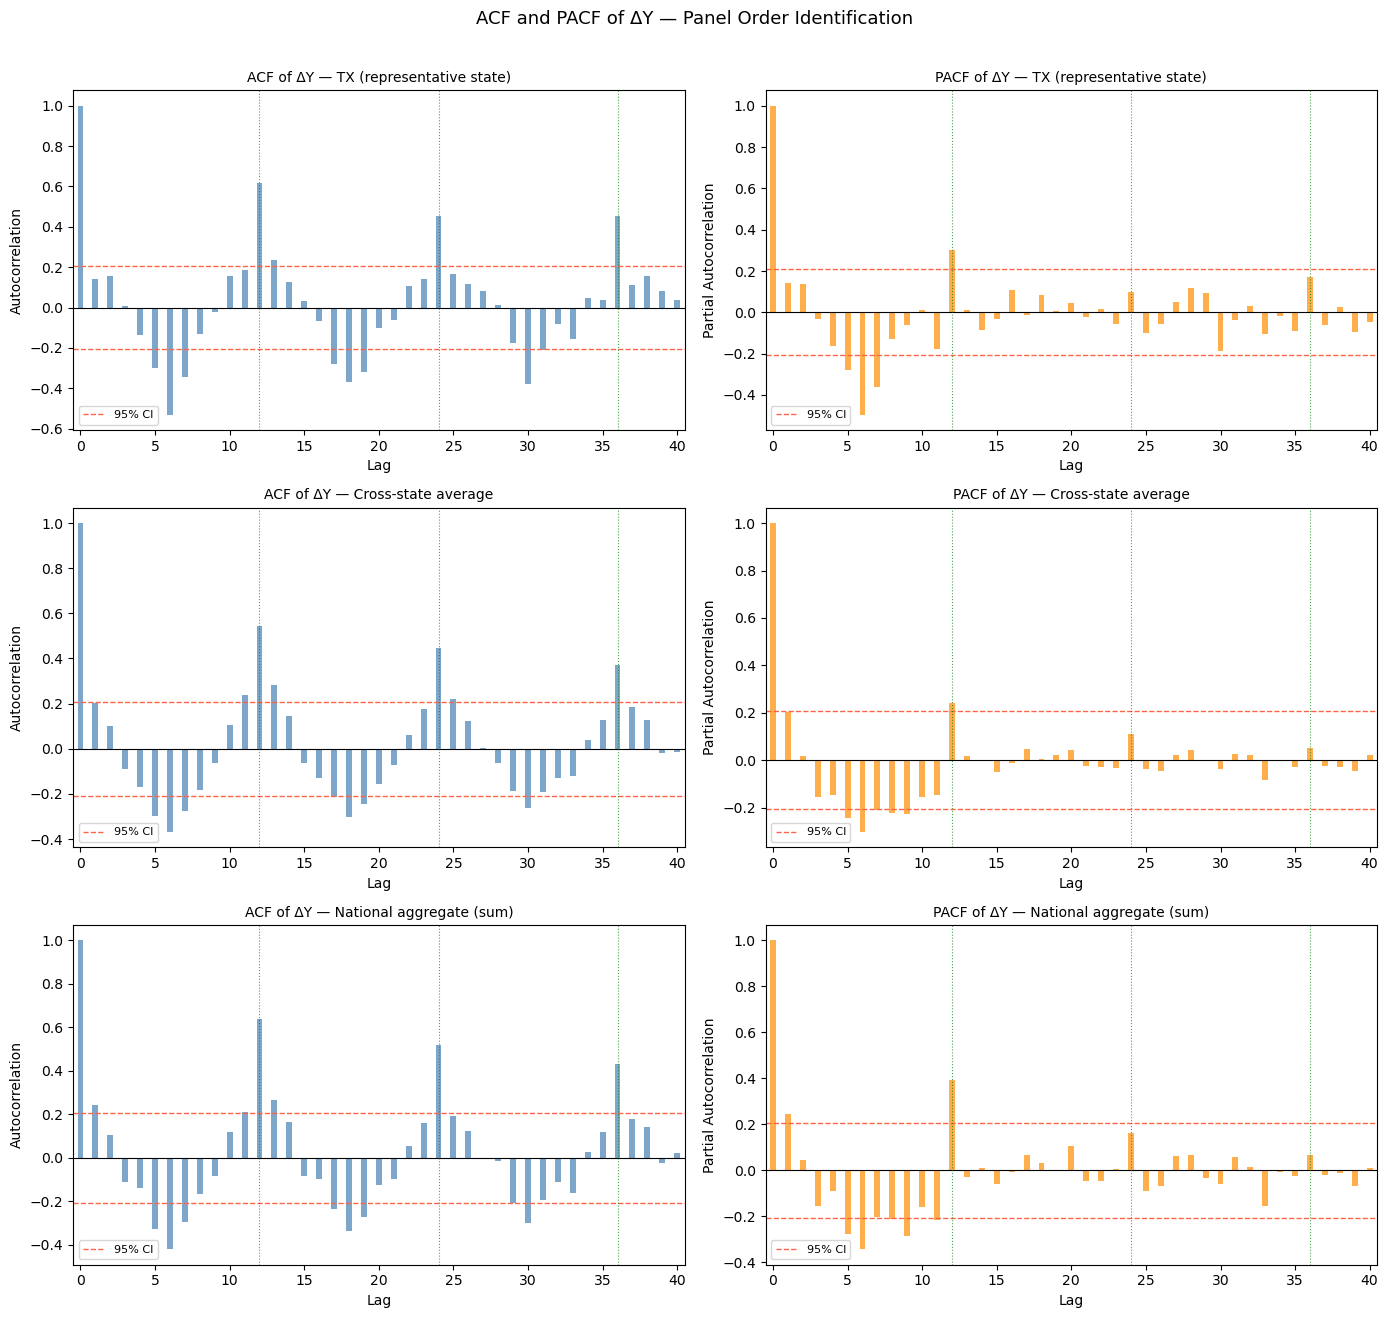

Interpretation guide:

  Non-seasonal (p, q):
    PACF cuts off after lag k → AR(p=k) suggested
    ACF cuts off after lag k  → MA(q=k) suggested
    Both decay slowly         → ARMA(p,q) with small p and q

  Seasonal (P, Q) at lags 12, 24:
    Significant spike at lag 12 in PACF only → SAR(P=1)
    Significant spike at lag 12 in ACF only  → SMA(Q=1)
    Spikes at both 12 and 24                 → consider P=1, Q=1
    No significant spikes at 12, 24          → P=Q=0

  Use the cross-state average row as the primary guide —
  it reflects the common panel structure rather than
  one state's idiosyncratic pattern.


In [6]:
# ── ACF and PACF Plots for Order Identification ───────────────────────────────
# Plot ACF and PACF of ΔY (first-differenced listing count) to guide selection
# of non-seasonal (p, q) and seasonal (P, Q)_12 orders.
#
# Reading guide:
#   Non-seasonal lags 1–11 : PACF cuts off → guides p
#                            ACF cuts off  → guides q
#   Seasonal lags 12, 24   : PACF cuts off → guides P
#                            ACF cuts off  → guides Q
#
# Because this is a pooled panel, we plot three series:
#   1. A representative single state (TX) — cleanest individual signal
#   2. The cross-state average ACF/PACF — smooths idiosyncratic state noise
#   3. The national aggregate (sum across states) — closest to national model

import warnings
warnings.simplefilter("ignore")

# ── Helper: compute average ACF/PACF across all states ───────────────────────
from statsmodels.tsa.stattools import acf, pacf

def mean_acf_pacf_across_states(train_df, col, nlags=40, diff=True):
    """
    Compute ACF and PACF for each state individually, then average across states.
    Averaging smooths idiosyncratic state-level noise and gives a more stable
    picture of the common serial structure in the panel.
    """
    acf_vals  = []
    pacf_vals = []

    for st, grp in train_df.groupby("state_abbr"):
        series = grp.sort_values("time")[col]
        if diff:
            series = series.diff().dropna()
        else:
            series = series.dropna()

        if len(series) < nlags + 2:
            continue

        try:
            acf_vals.append(acf(series,   nlags=nlags, fft=True))
            pacf_vals.append(pacf(series, nlags=nlags, method="ywm"))
        except Exception:
            continue

    mean_acf  = np.mean(acf_vals,  axis=0)
    mean_pacf = np.mean(pacf_vals, axis=0)
    n_states  = len(acf_vals)
    # Approximate 95% CI based on average series length
    avg_len   = np.mean([
        len(grp.sort_values("time")["Y"].diff().dropna())
        for _, grp in train_df.groupby("state_abbr")
    ])
    ci_bound  = 1.96 / np.sqrt(avg_len)

    return mean_acf, mean_pacf, ci_bound, n_states

NLAGS = 40

# ── Series 1: TX representative state ────────────────────────────────────────
tx_series = (
    train[train["state_abbr"] == "TX"]
    .sort_values("time")["Y"]
    .diff().dropna()
)

# ── Series 2: Cross-state average ACF/PACF ───────────────────────────────────
mean_acf_vals, mean_pacf_vals, ci_avg, n_st = mean_acf_pacf_across_states(
    train, "Y", nlags=NLAGS, diff=True
)

# ── Series 3: National aggregate ─────────────────────────────────────────────
agg_series = (
    train.groupby("time")["Y"].sum()
    .sort_index()
    .diff().dropna()
)

lags = np.arange(0, NLAGS + 1)
ci_tx  = 1.96 / np.sqrt(len(tx_series))
ci_agg = 1.96 / np.sqrt(len(agg_series))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
fig.suptitle("ACF and PACF of ΔY — Panel Order Identification", fontsize=13, y=1.01)

plot_specs = [
    (tx_series,     ci_tx,  "TX (representative state)",   axes[0]),
    (None,          ci_avg, "Cross-state average",          axes[1]),  # uses precomputed
    (agg_series,    ci_agg, "National aggregate (sum)",     axes[2]),
]

for i, (series, ci, title, ax_row) in enumerate(plot_specs):
    ax_acf, ax_pacf = ax_row

    if i == 1:
        # Use precomputed mean ACF/PACF
        acf_to_plot  = mean_acf_vals
        pacf_to_plot = mean_pacf_vals
    else:
        acf_to_plot  = acf(series,  nlags=NLAGS, fft=True)
        pacf_to_plot = pacf(series, nlags=NLAGS, method="ywm")

    # ACF
    ax_acf.bar(lags, acf_to_plot, color="steelblue", alpha=0.7, width=0.4)
    ax_acf.axhline(0,    color="black",  linewidth=0.8)
    ax_acf.axhline( ci,  color="tomato", linewidth=1.0, linestyle="--", label="95% CI")
    ax_acf.axhline(-ci,  color="tomato", linewidth=1.0, linestyle="--")
    for sl in [12, 24, 36]:
        ax_acf.axvline(sl, color="green", linewidth=0.8, linestyle=":", alpha=0.7)
    ax_acf.set_title(f"ACF of ΔY — {title}", fontsize=10)
    ax_acf.set_xlabel("Lag")
    ax_acf.set_ylabel("Autocorrelation")
    ax_acf.legend(fontsize=8)
    ax_acf.set_xlim(-0.5, NLAGS + 0.5)

    # PACF
    ax_pacf.bar(lags, pacf_to_plot, color="darkorange", alpha=0.7, width=0.4)
    ax_pacf.axhline(0,    color="black",  linewidth=0.8)
    ax_pacf.axhline( ci,  color="tomato", linewidth=1.0, linestyle="--", label="95% CI")
    ax_pacf.axhline(-ci,  color="tomato", linewidth=1.0, linestyle="--")
    for sl in [12, 24, 36]:
        ax_pacf.axvline(sl, color="green", linewidth=0.8, linestyle=":", alpha=0.7)
    ax_pacf.set_title(f"PACF of ΔY — {title}", fontsize=10)
    ax_pacf.set_xlabel("Lag")
    ax_pacf.set_ylabel("Partial Autocorrelation")
    ax_pacf.legend(fontsize=8)
    ax_pacf.set_xlim(-0.5, NLAGS + 0.5)

plt.tight_layout()
plt.savefig("state_acf_pacf_dY.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Interpretation guide ──────────────────────────────────────────────────────
print("Interpretation guide:")
print()
print("  Non-seasonal (p, q):")
print("    PACF cuts off after lag k → AR(p=k) suggested")
print("    ACF cuts off after lag k  → MA(q=k) suggested")
print("    Both decay slowly         → ARMA(p,q) with small p and q")
print()
print("  Seasonal (P, Q) at lags 12, 24:")
print("    Significant spike at lag 12 in PACF only → SAR(P=1)")
print("    Significant spike at lag 12 in ACF only  → SMA(Q=1)")
print("    Spikes at both 12 and 24                 → consider P=1, Q=1")
print("    No significant spikes at 12, 24          → P=Q=0")
print()
print("  Use the cross-state average row as the primary guide —")
print("  it reflects the common panel structure rather than")
print("  one state's idiosyncratic pattern.")

## SARIMAX Data Preparation

Prepare the exogenous regressor matrix for the pooled state-level SARIMAX. The transformation and centering rules follow the national model, extended with state-specific centering for $U_{it}$ and $H_{it}$, and panel-level dummy variables for industry groups.

**Centering decisions:**
- $\widetilde{\Delta L}_t = \Delta L_t - \overline{\Delta L}$: first difference of $L_t$, centered on its training-window mean (same scalar for all states — $L_t$ is national)
- $\tilde{U}_{it} = U_{it} - \bar{U}_i$: unemployment in levels, centered on **state-specific** training-window mean
- $\tilde{H}_{it} = H_{it} - \bar{H}_i$: HPI in levels, centered on **state-specific** training-window mean — not differenced; quarterly source data
- $\Delta S_{it}$: first difference of permits, not centered (does not enter any interaction term)
- $\widetilde{\Delta L}_t \times \tilde{U}_{it}$: unemployment interaction
- $D_{ki}$ dummies: one dummy per non-reference industry group, constructed via `pd.get_dummies()`
- $\widetilde{\Delta L}_t \times D_{ki}$: industry interaction — identifies differential lock-in effect per group

All centering constants are computed on the **training set only** and applied mechanically to the test set to prevent data leakage.


In [7]:
# ── Compute centering constants from training set ─────────────────────────────
# L_t  : national → single scalar mean of dL over training window
# U_it : state-specific → per-state mean of U over training window
# H_it : state-specific → per-state mean of H over training window (levels, centered)

# National dL centering
nat_train_L = train.drop_duplicates("time").set_index("time")["L"].sort_index()
dL_mean = nat_train_L.diff().dropna().mean()

# State-specific U and H centering means (training set only)
U_means = train.groupby("state_abbr")["U"].mean().rename("U_mean")
H_means = train.groupby("state_abbr")["H"].mean().rename("H_mean")

print(f"dL centering mean (training) : {dL_mean:.4f}")
print()
print("U centering means by state (first 10):")
print(U_means.head(10).round(3).to_string())
print()
print("H centering means by state (first 10):")
print(H_means.head(10).round(2).to_string())

def make_exog_state(df_in, dL_mean, U_means, H_means, ref_group, non_ref_groups):
    """
    Build the SARIMAX exog matrix for the pooled state panel.

    Variables:
      dL_c  : centered first difference of lock-in premium (national)
      U_c   : centered unemployment levels (state-specific mean)
      H_c   : centered HPI levels (state-specific mean) — not differenced;
              quarterly source data; stationarity not formally tested
      dS    : first difference of permits
      LxU   : dL_c × U_c interaction
      D_k   : industry group dummies via pd.get_dummies (reference group omitted)
      LxD_k : dL_c × D_k interaction for each non-reference group
    """
    out_rows = []

    for state, grp in df_in.groupby("state_abbr", sort=True):
        grp = grp.sort_values("time").copy()

        U_mean_i = U_means.loc[state]
        H_mean_i = H_means.loc[state]
        ig        = grp["industry_group"].iloc[0]

        dL  = grp["L"].diff() - dL_mean
        U_c = grp["U"] - U_mean_i
        H_c = grp["H"] - H_mean_i        # levels, centered on state mean
        dS  = grp["S"].diff()
        LxU = dL * U_c

        ind_dummies = {g: int(ig == g) for g in non_ref_groups}
        LxD         = {f"LxD_{g}": dL * int(ig == g) for g in non_ref_groups}

        for idx in grp.index:
            row = {
                "time"      : grp.loc[idx, "time"],
                "state_abbr": state,
                "Y"         : grp.loc[idx, "Y"],
                "dL_c"      : dL.loc[idx],
                "U_c"       : U_c.loc[idx],
                "H_c"       : H_c.loc[idx],   # HPI centered levels
                "dS"        : dS.loc[idx],
                "LxU"       : LxU.loc[idx],
            }
            for g in non_ref_groups:
                row[f"D_{g}"]   = ind_dummies[g]
                row[f"LxD_{g}"] = LxD[f"LxD_{g}"].loc[idx]
            out_rows.append(row)

    result = pd.DataFrame(out_rows).dropna()
    result = result.sort_values(["state_abbr", "time"]).reset_index(drop=True)
    return result

# Build exog matrices
train_exog_df = make_exog_state(train, dL_mean, U_means, H_means,
                                REFERENCE_GROUP, NON_REF_GROUPS)
test_exog_df  = make_exog_state(test,  dL_mean, U_means, H_means,
                                REFERENCE_GROUP, NON_REF_GROUPS)

exog_cols = [c for c in train_exog_df.columns if c not in ["time", "state_abbr", "Y"]]

print(f"\nTrain exog shape : {train_exog_df.shape}")
print(f"Test  exog shape : {test_exog_df.shape}")
print()
print("Exog columns:", exog_cols)
print()
print("Sample (first 3 rows):")
print(train_exog_df[["time", "state_abbr"] + exog_cols].head(3).round(4).to_string(index=False))

dL centering mean (training) : 0.0096

U centering means by state (first 10):
state_abbr
AK    5.947
AL    3.900
AR    3.898
AZ    5.008
CA    5.652
CO    3.796
CT    4.776
DE    4.649
FL    4.319
GA    4.267

H centering means by state (first 10):
state_abbr
AK    356.69
AL    369.05
AR    323.72
AZ    496.76
CA    724.57
CO    639.81
CT    458.11
DE    523.47
FL    549.18
GA    433.45

Train exog shape : (4450, 18)
Test  exog shape : (1100, 18)

Exog columns: ['dL_c', 'U_c', 'H_c', 'dS', 'LxU', 'D_Construction & Development', 'LxD_Construction & Development', 'D_Finance & Corporate Services', 'LxD_Finance & Corporate Services', 'D_Manufacturing & Industrial', 'LxD_Manufacturing & Industrial', 'D_Tech/Knowledge & Innovation', 'LxD_Tech/Knowledge & Innovation', 'D_Leisure & Hospitality', 'LxD_Leisure & Hospitality']

Sample (first 3 rows):
      time state_abbr    dL_c     U_c      H_c     dS     LxU  D_Construction & Development  LxD_Construction & Development  D_Finance & Corporate S

## SARIMAX Model

### Order selection

Per Plan A, the ARIMA order is **carried forward from the national model** without re-selection. From the national model notebook, the selected order was:

> **SARIMAX(1,1,1)(1,1,1,12)** — review and update the `BEST_ORDER` / `BEST_S_ORDER` constants below if a different order was selected in your national model run.

The pooled panel is stacked as a single long time series (all states concatenated). SARIMAX treats the stacked series as one long univariate outcome; the state fixed effects and industry dummies in the exog matrix handle the cross-sectional structure. This is the standard approach for applying SARIMAX to a balanced panel when the cross-section is captured entirely through exogenous regressors.


In [8]:
# ── SARIMAX Order Search ───────────────────────────────────────────────────────
# Candidate orders are informed by the ACF/PACF plots above:
#   - Slow decay at seasonal lags 12, 24, 36 in ACF → D=1 warranted
#   - ACF cuts off after lag 1 non-seasonally → q=1
#   - PACF significant at lags 1-2 → p=1 or p=2
#   - ACF spike at lag 12 after D=1 → Q=1
#   - PACF spike at lag 12 → P=0 or P=1
#
# Candidates are grouped by priority derived from the plots:
#   Priority 1: D=1 with P/Q combinations supported by ACF/PACF
#   Priority 2: D=0 candidates for comparison (includes national model order)
#   Priority 3: Richer specifications for robustness
#
# method='lbfgs' is used throughout for faster convergence on large N.

candidate_orders = [
    # ── Priority 1: D=1 — strongly supported by ACF/PACF seasonal decay ──────
    ((0, 1, 1), (0, 1, 1, 12)),   # national model order with D=1 — primary candidate
    ((1, 1, 1), (0, 1, 1, 12)),   # ARMA(1,1) + seasonal MA
    ((1, 1, 1), (1, 1, 1, 12)),   # full ARMA(1,1) + SAR(1) SMA(1)
    ((1, 1, 1), (1, 1, 0, 12)),   # ARMA(1,1) + SAR(1) only
    ((2, 1, 1), (0, 1, 1, 12)),   # AR(2) — PACF significant at lag 2
    ((2, 1, 1), (1, 1, 1, 12)),   # richer AR(2) + full seasonal

    # ── Priority 2: D=0 — for comparison against D=1 candidates ─────────────
    ((0, 1, 1), (0, 0, 1, 12)),   # national model order (D=0)
    ((1, 1, 1), (1, 0, 0, 12)),   # current grid search winner
    ((1, 1, 1), (1, 0, 1, 12)),   # SAR(1) SMA(1) without seasonal differencing
    ((1, 1, 0), (1, 0, 0, 12)),   # AR(1) only
    ((1, 1, 1), (0, 0, 1, 12)),   # ARMA(1,1) + SMA(1)

    # ── Priority 3: Richer specifications ────────────────────────────────────
    ((2, 1, 0), (0, 1, 1, 12)),   # pure AR(2) + seasonal MA
    ((1, 1, 1), (2, 1, 1, 12)),   # SAR(2) — check lag-24 PACF signal
]

# ── Prepare arrays for metrics and XGBoost (not used in SARIMAX fit) ─────────
y_train = train_exog_df["Y"].values
y_test  = test_exog_df["Y"].values

print(f"Stacked training Y    : {len(y_train):,} observations")
print(f"Stacked test Y        : {len(y_test):,} observations")
print(f"Exog matrix (train)   : {train_exog_df[exog_cols].shape}")
print(f"Candidates to search  : {len(candidate_orders)}")
print()
print("Running order search — this may take several minutes...")
print()

grid_results = []

for order, s_order in candidate_orders:
    try:
        mod = SARIMAX(
            train_exog_df["Y"],            # DataFrame — preserves index
            exog=train_exog_df[exog_cols], # DataFrame — preserves column names
            order=order,
            seasonal_order=s_order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = mod.fit(disp=False, maxiter=300, method="lbfgs")
        converged = fit.mle_retvals.get("converged", True)

        grid_results.append({
            "order"    : order,
            "s_order"  : s_order,
            "aic"      : round(fit.aic, 2),
            "bic"      : round(fit.bic, 2),
            "converged": converged,
        })
        status = "✓" if converged else "~"
        print(f"  {status} SARIMAX{order}x{s_order}  AIC={fit.aic:,.2f}  BIC={fit.bic:,.2f}")

    except Exception as e:
        grid_results.append({
            "order"    : order,
            "s_order"  : s_order,
            "aic"      : np.nan,
            "bic"      : np.nan,
            "converged": False,
        })
        print(f"  ✗ SARIMAX{order}x{s_order}  FAILED: {e}")

grid_df = (
    pd.DataFrame(grid_results)
    .sort_values(["aic", "bic"], na_position="last")
    .reset_index(drop=True)
)

print()
print("Order search results (sorted by AIC):")
print(grid_df.to_string(index=False))

# ── Summarise D=1 vs D=0 comparison ──────────────────────────────────────────
d1_best = grid_df[grid_df["s_order"].apply(lambda x: x[1] == 1)].iloc[0]
d0_best = grid_df[grid_df["s_order"].apply(lambda x: x[1] == 0)].iloc[0]

print()
print("D=1 vs D=0 comparison (best of each group):")
print(f"  Best D=1 : SARIMAX{d1_best['order']}x{d1_best['s_order']}  AIC={d1_best['aic']:,.2f}")
print(f"  Best D=0 : SARIMAX{d0_best['order']}x{d0_best['s_order']}  AIC={d0_best['aic']:,.2f}")
if d1_best["aic"] < d0_best["aic"]:
    print(f"  → D=1 preferred by AIC, consistent with ACF/PACF seasonal unit root signal.")
else:
    print(f"  → D=0 preferred by AIC despite ACF/PACF suggesting seasonal unit root.")
    print(f"    Consider whether the pooled panel structure is dampening the seasonal signal.")

# ── Select best converged order ───────────────────────────────────────────────
valid_grid = grid_df.dropna(subset=["aic", "bic"])

if valid_grid.empty:
    raise ValueError("All SARIMAX fits failed. Check data alignment and exog matrix.")

best_row     = valid_grid.iloc[0]
BEST_ORDER   = best_row["order"]
BEST_S_ORDER = best_row["s_order"]

# ── Compare to national model order ──────────────────────────────────────────
NATIONAL_ORDER   = (0, 1, 1)
NATIONAL_S_ORDER = (0, 1, 1, 12)

nat_row = valid_grid[
    (valid_grid["order"]   == NATIONAL_ORDER) &
    (valid_grid["s_order"] == NATIONAL_S_ORDER)
]

print()
print(f"National model order  : SARIMAX{NATIONAL_ORDER}x{NATIONAL_S_ORDER}"
      + (f"  AIC={nat_row.iloc[0]['aic']:,.2f}" if not nat_row.empty else "  (not in grid)"))
print(f"State model best order: SARIMAX{BEST_ORDER}x{BEST_S_ORDER}"
      f"  AIC={best_row['aic']:,.2f}")

if (BEST_ORDER == NATIONAL_ORDER) and (BEST_S_ORDER == NATIONAL_S_ORDER):
    print("→ State-level search confirms the national model order. Proceeding with it.")
else:
    if not nat_row.empty:
        aic_diff = best_row["aic"] - nat_row.iloc[0]["aic"]
        print(f"→ State-level search prefers a different order.")
        print(f"  AIC improvement over national order: {abs(aic_diff):,.2f}")
    else:
        print(f"→ National order was not in the candidate grid or failed to fit.")
    print(f"  Using state-level best order for the final fit.")

Stacked training Y    : 4,450 observations
Stacked test Y        : 1,100 observations
Exog matrix (train)   : (4450, 15)
Candidates to search  : 13

Running order search — this may take several minutes...

  ✓ SARIMAX(0, 1, 1)x(0, 1, 1, 12)  AIC=79,128.65  BIC=79,250.14
  ✓ SARIMAX(1, 1, 1)x(0, 1, 1, 12)  AIC=79,185.77  BIC=79,313.66
  ✓ SARIMAX(1, 1, 1)x(1, 1, 1, 12)  AIC=78,975.75  BIC=79,110.03
  ✓ SARIMAX(1, 1, 1)x(1, 1, 0, 12)  AIC=79,428.32  BIC=79,556.22
  ✓ SARIMAX(2, 1, 1)x(0, 1, 1, 12)  AIC=79,152.83  BIC=79,287.12
  ✓ SARIMAX(2, 1, 1)x(1, 1, 1, 12)  AIC=78,937.96  BIC=79,078.64
  ✓ SARIMAX(0, 1, 1)x(0, 0, 1, 12)  AIC=79,259.12  BIC=79,380.67
  ✓ SARIMAX(1, 1, 1)x(1, 0, 0, 12)  AIC=79,001.19  BIC=79,129.14
  ✓ SARIMAX(1, 1, 1)x(1, 0, 1, 12)  AIC=78,864.05  BIC=78,998.39
  ✓ SARIMAX(1, 1, 0)x(1, 0, 0, 12)  AIC=78,999.24  BIC=79,120.79
  ✓ SARIMAX(1, 1, 1)x(0, 0, 1, 12)  AIC=79,232.56  BIC=79,360.50
  ✓ SARIMAX(2, 1, 0)x(0, 1, 1, 12)  AIC=79,142.93  BIC=79,270.82
  ✓ SARIMAX(1,

### Important note on pooled SARIMAX

A single SARIMAX applied to a stacked 5,650-row panel is computationally intensive. The model is estimated with `maxiter=300` and `method='lbfgs'`. Convergence warnings may appear for some candidate orders — the best-converging specification is selected.

In [9]:
# ── Common ARIMA order from national model ────────────────────────────────────
print(f"Imposing national model order : SARIMAX{BEST_ORDER}x{BEST_S_ORDER}")
print()

# ── Prepare stacked arrays for XGBoost and metrics (not used for SARIMAX fit) ─
y_train       = train_exog_df["Y"].values
y_test        = test_exog_df["Y"].values

print(f"Stacked training Y    : {len(y_train):,} observations")
print(f"Stacked test Y        : {len(y_test):,} observations")
print(f"Exog matrix (train)   : {train_exog_df[exog_cols].shape}")

# ── Fit pooled SARIMAX ────────────────────────────────────────────────────────
print("\nFitting pooled SARIMAX — this may take several minutes...")

sarimax_model = SARIMAX(
    train_exog_df["Y"],           # DataFrame Series — preserves index
    exog=train_exog_df[exog_cols], # DataFrame — preserves column names in summary
    order= BEST_ORDER,
    seasonal_order= BEST_S_ORDER,
    trend="c",
    enforce_stationarity=False,   # required when d=1
    enforce_invertibility=False,
)

sarimax_fit = sarimax_model.fit(disp=False, maxiter=300, method="lbfgs")

print(sarimax_fit.summary())

Imposing national model order : SARIMAX(1, 1, 1)x(2, 1, 1, 12)

Stacked training Y    : 4,450 observations
Stacked test Y        : 1,100 observations
Exog matrix (train)   : (4450, 15)

Fitting pooled SARIMAX — this may take several minutes...
                                     SARIMAX Results                                      
Dep. Variable:                                  Y   No. Observations:                 4450
Model:             SARIMAX(1, 1, 1)x(2, 1, 1, 12)   Log Likelihood              -39332.020
Date:                            Wed, 18 Mar 2026   AIC                          78708.040
Time:                                    19:14:49   BIC                          78848.666
Sample:                                         0   HQIC                         78757.641
                                           - 4450                                         
Covariance Type:                              opg                                         
                            

## SARIMAX Residual Diagnostics

Verify that residuals are white noise. For a pooled panel, some residual autocorrelation is expected if cross-sectional dependence exists (state economies respond together to national shocks). The Ljung-Box test is a necessary but not sufficient check under this structure.


Ljung-Box test on pooled residuals:
     lb_stat  lb_pvalue
6   125.5772        0.0
12  220.6797        0.0
18  282.0523        0.0
24  309.5139        0.0

WARNING — residual autocorrelation detected.
          In a pooled panel this may reflect cross-sectional dependence
          rather than a model misspecification. Report as a limitation.


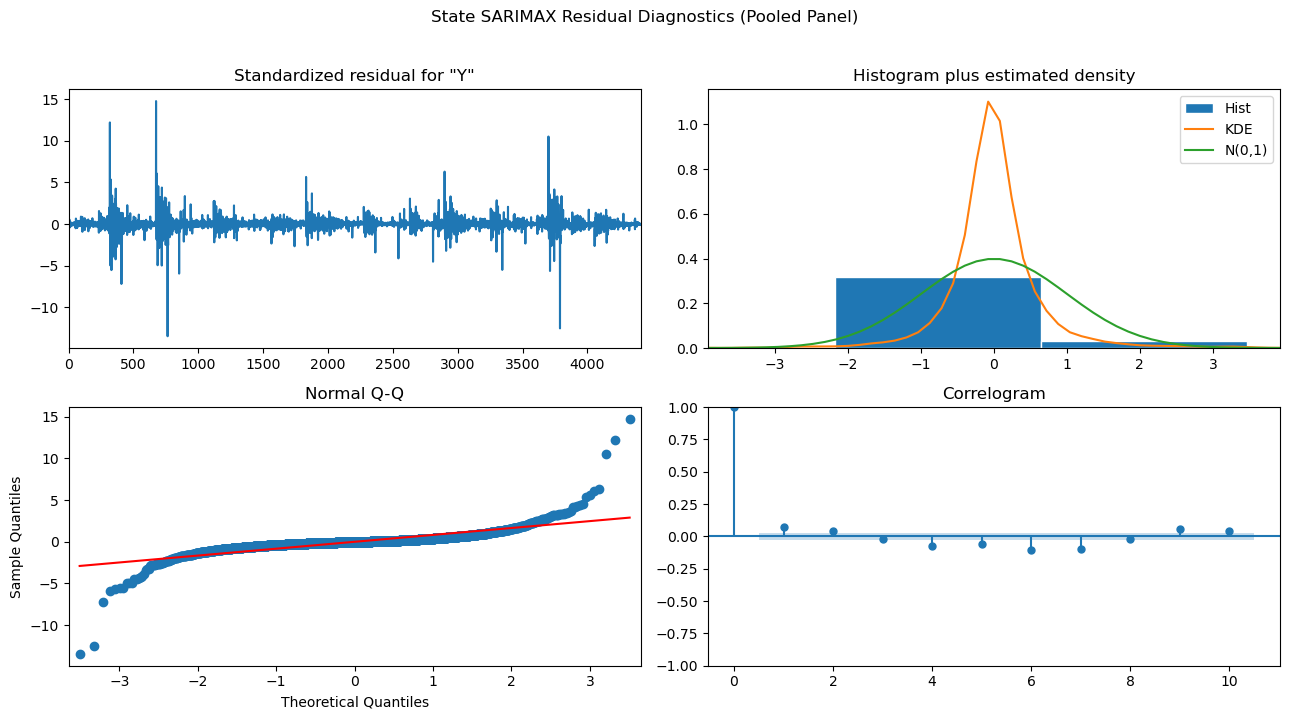

In [10]:
# ── Ljung-Box test ────────────────────────────────────────────────────────────
resid = sarimax_fit.resid
# Drop leading NaNs that arise from differencing
resid = pd.Series(resid).dropna()

lb = acorr_ljungbox(resid, lags=[6, 12, 18, 24], return_df=True)
print("Ljung-Box test on pooled residuals:")
print(lb.round(4))
print()
if (lb["lb_pvalue"] > 0.05).all():
    print("PASS — no significant residual autocorrelation at any tested lag.")
else:
    print("WARNING — residual autocorrelation detected.")
    print("          In a pooled panel this may reflect cross-sectional dependence")
    print("          rather than a model misspecification. Report as a limitation.")

# ── Residual diagnostic plots ─────────────────────────────────────────────────
fig = sarimax_fit.plot_diagnostics(figsize=(13, 7))
fig.suptitle("State SARIMAX Residual Diagnostics (Pooled Panel)", y=1.02)
fig.tight_layout()
fig.savefig("state_sarimax_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()

## SARIMAX Test Set Forecast

Produce out-of-sample forecasts for the test period. The plot shows aggregate actual vs forecast (summed across all states) as a single national-level comparison, then individual state-level plots for a representative sample.


State SARIMAX RMSE (per state-month) : 8,246.0
State SARIMAX MAE  (per state-month) : 4,736.6


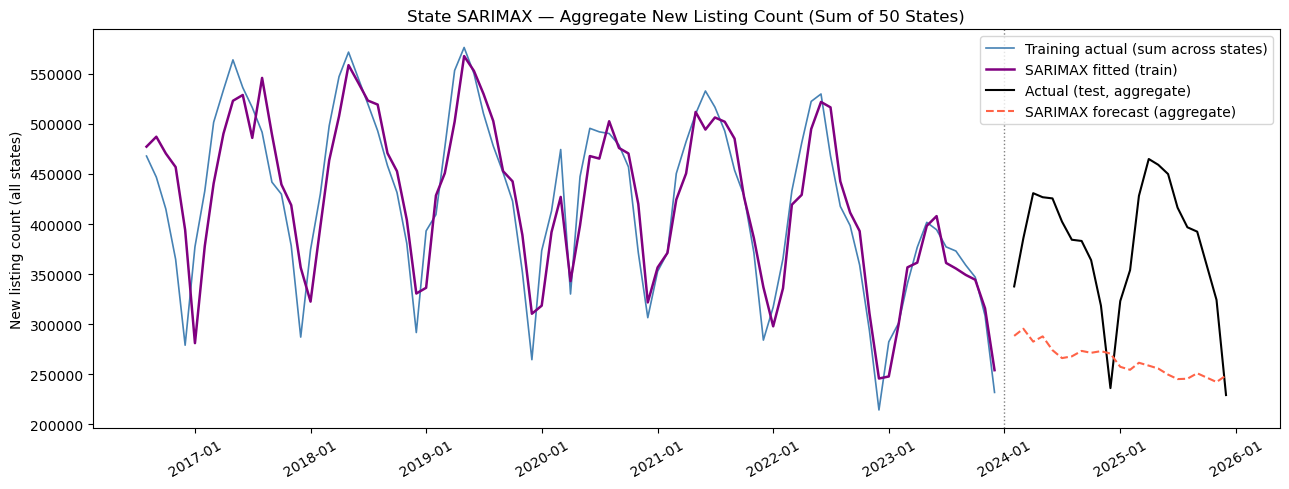

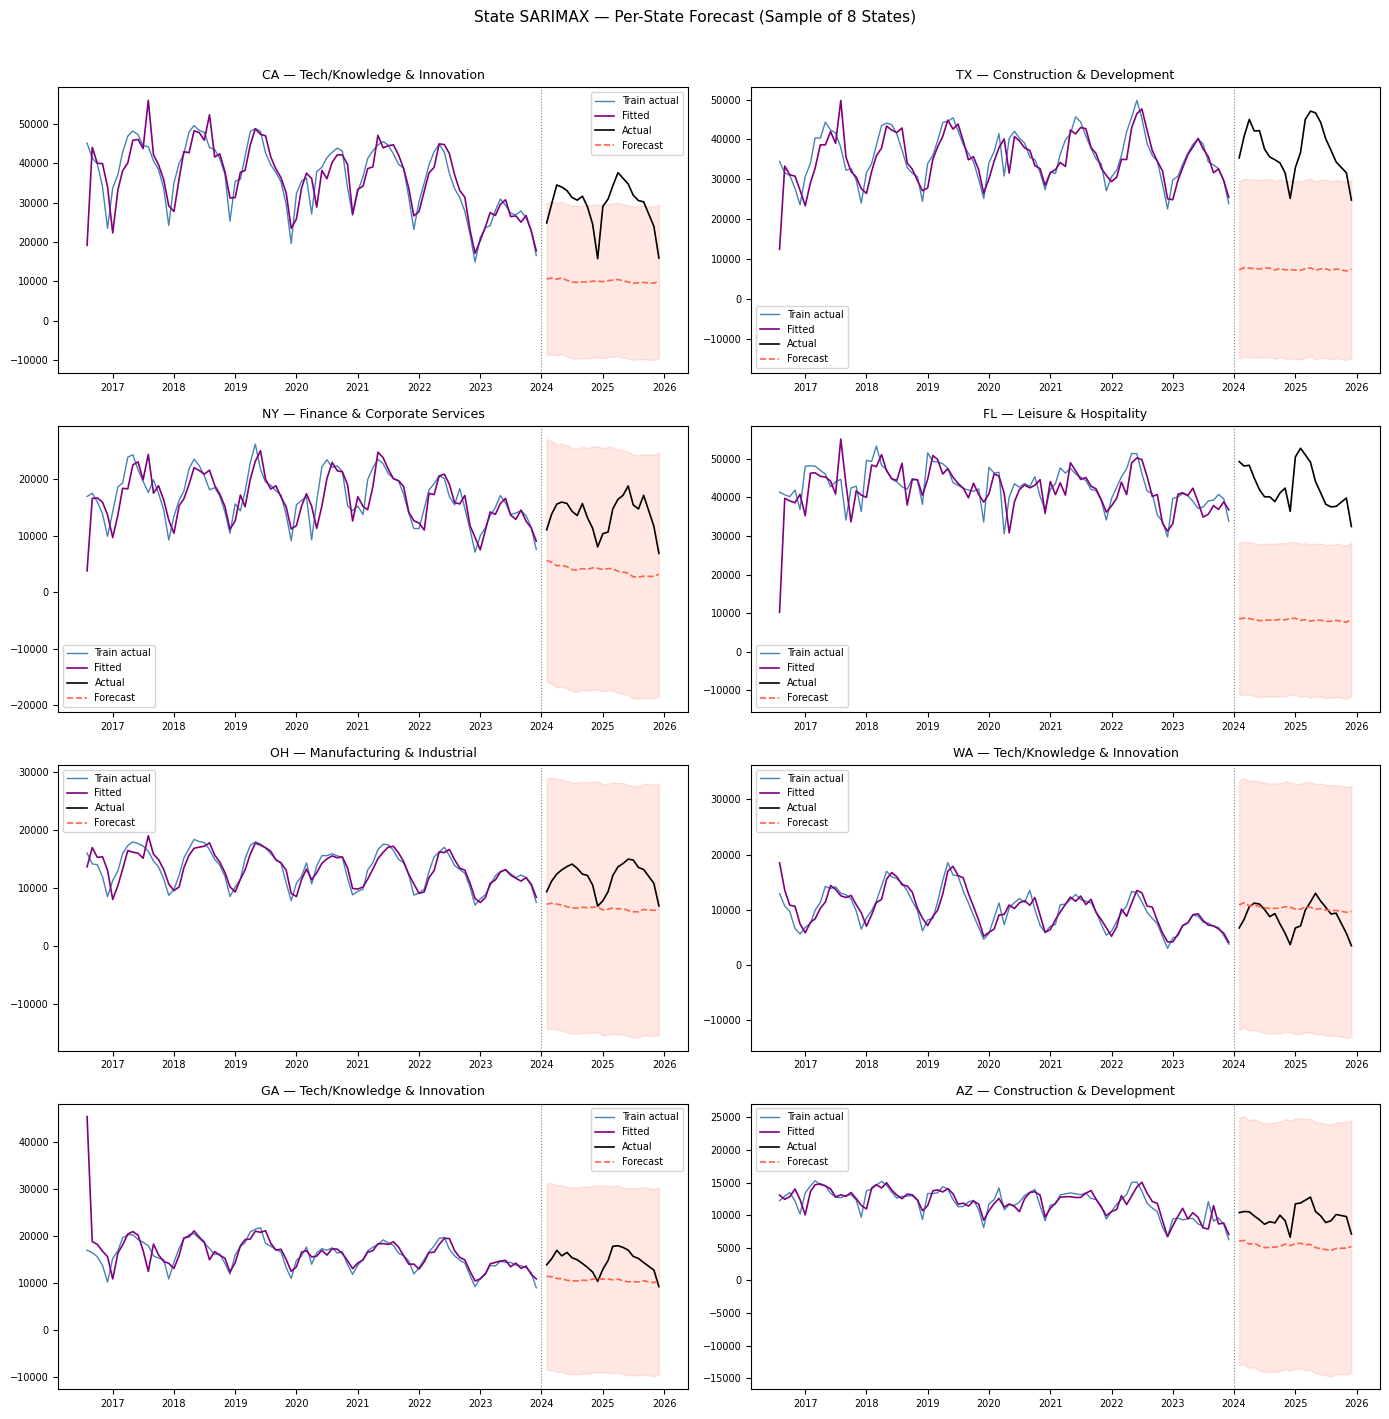

In [11]:
# ── Out-of-sample forecast ────────────────────────────────────────────────────
forecast_obj = sarimax_fit.get_forecast(
    steps=len(test_exog_df),
    exog=test_exog_df[exog_cols],      # DataFrame — consistent with fit
)

sarimax_pred_arr = forecast_obj.predicted_mean.values
sarimax_ci       = forecast_obj.conf_int(alpha=0.05)  # DataFrame with named cols

# ── In-sample fitted values ────────────────────────────────────────────────────
sarimax_fitted_arr = sarimax_fit.fittedvalues.values

# Attach predictions and CI back to dataframes
test_exog_df = test_exog_df.copy()
test_exog_df["sarimax_pred"] = sarimax_pred_arr
test_exog_df["ci_lower"]     = sarimax_ci.iloc[:, 0].values
test_exog_df["ci_upper"]     = sarimax_ci.iloc[:, 1].values

train_exog_df = train_exog_df.copy()
train_exog_df["sarimax_fitted"] = sarimax_fitted_arr[:len(train_exog_df)]

# ── Metrics ───────────────────────────────────────────────────────────────────
sarimax_rmse = np.sqrt(mean_squared_error(y_test, sarimax_pred_arr))
sarimax_mae  = mean_absolute_error(y_test, sarimax_pred_arr)
print(f"State SARIMAX RMSE (per state-month) : {sarimax_rmse:,.1f}")
print(f"State SARIMAX MAE  (per state-month) : {sarimax_mae:,.1f}")

# ── Aggregate (national sum) plot — with fitted line ─────────────────────────
agg_train_actual = train_exog_df.groupby("time")["Y"].sum()
agg_train_fitted = train_exog_df.groupby("time")["sarimax_fitted"].sum()
agg_test_actual  = test_exog_df.groupby("time")["Y"].sum()
agg_test_pred    = test_exog_df.groupby("time")["sarimax_pred"].sum()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(agg_train_actual.index, agg_train_actual.values,
        color="steelblue", linewidth=1.2, label="Training actual (sum across states)")
ax.plot(agg_train_fitted.index, agg_train_fitted.values,
        color="purple", linewidth=1.8, linestyle="-", label="SARIMAX fitted (train)")
ax.plot(agg_test_actual.index, agg_test_actual.values,
        color="black", linewidth=1.5, label="Actual (test, aggregate)")
ax.plot(agg_test_pred.index, agg_test_pred.values,
        color="tomato", linewidth=1.5, linestyle="--", label="SARIMAX forecast (aggregate)")
ax.axvline(pd.Timestamp(split_date), color="gray", linestyle=":", linewidth=1)
ax.set_title("State SARIMAX — Aggregate New Listing Count (Sum of 50 States)")
ax.set_ylabel("New listing count (all states)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("state_sarimax_forecast_aggregate.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Per-state sample plot — with fitted line ──────────────────────────────────
sample_states = ["CA", "TX", "NY", "FL", "OH", "WA", "GA", "AZ"]
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, st in zip(axes, sample_states):
    tr = train_exog_df[train_exog_df["state_abbr"] == st]
    te = test_exog_df[test_exog_df["state_abbr"] == st]
    ax.plot(tr["time"], tr["Y"],
            color="steelblue", linewidth=1.0, label="Train actual")
    ax.plot(tr["time"], tr["sarimax_fitted"],
            color="purple", linewidth=1.2, linestyle="-", label="Fitted")
    ax.plot(te["time"], te["Y"],
            color="black", linewidth=1.2, label="Actual")
    ax.plot(te["time"], te["sarimax_pred"],
            color="tomato", linewidth=1.2, linestyle="--", label="Forecast")
    ax.fill_between(te["time"], te["ci_lower"], te["ci_upper"],
                    color="tomato", alpha=0.15)
    ax.axvline(pd.Timestamp(split_date), color="gray", linestyle=":", linewidth=0.8)
    ig = INDUSTRY_GROUPS[st]
    ax.set_title(f"{st} — {ig}", fontsize=9)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.suptitle("State SARIMAX — Per-State Forecast (Sample of 8 States)", y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig("state_sarimax_forecast_sample_states.png", dpi=120, bbox_inches="tight")
plt.show()

## SARIMAX Coefficient Interpretation

Extract and display the key coefficients of interest:

- $\hat{\beta}_1$ (`dL_c`): lock-in effect on new listings at mean state unemployment and for the reference industry group
- $\hat{\beta}_2$ (`U_c`): unemployment effect at mean lock-in change rate
- $\hat{\beta}_3$ (`H_c`): HPI level effect — a positive coefficient indicates that states with HPI above their own historical mean have more listings, consistent with equity-unlocking; a negative coefficient indicates affordability constraints suppress listings
- $\hat{\beta}_4$ (`dS`): permits change effect
- $\hat{\beta}_5$ (`LxU`): unemployment interaction — does lock-in bite harder when unemployment is elevated?
- $\hat{\gamma}_k$ (`D_k`): baseline listing activity difference for industry group $k$ vs reference group
- $\hat{\lambda}_k$ (`LxD_k`): lock-in effect differential for industry group $k$ vs reference group — a negative $\hat{\lambda}_k$ indicates the lock-in effect is stronger in group $k$

**Note on H_c:** HPI enters as centered levels rather than first differences due to the quarterly source frequency. The state-specific centering means $\hat{\beta}_3$ captures the within-state effect of HPI deviating above or below its own historical mean, net of the baseline level absorbed by the industry group dummies.


In [12]:
# ── Map exog_cols back to parameter names in the fitted model ─────────────────
param_names = sarimax_fit.param_names

arima_prefixes = ("ar.", "ma.", "sigma2", "drift", "intercept",
                  "sar.", "sma.", "season")
exog_start = next(
    i for i, n in enumerate(param_names)
    if not any(n.lower().startswith(p) for p in arima_prefixes)
)

print(f"Exog block starts at parameter index : {exog_start}")
print(f"Number of exog params expected       : {len(exog_cols)}")
print(f"Number of exog params in model       : {len(param_names) - exog_start}")
print()

# Build coefficient table — H_c replaces dH
key_vars = ["dL_c", "U_c", "H_c", "dS", "LxU"] +            [f"D_{g}" for g in NON_REF_GROUPS] +            [f"LxD_{g}" for g in NON_REF_GROUPS]

ci = sarimax_fit.conf_int()
ci.columns = ["ci_lower", "ci_upper"]

rows = []
for var in key_vars:
    if var not in exog_cols:
        continue
    pos = exog_start + exog_cols.index(var)
    if pos >= len(param_names):
        continue
    pname = param_names[pos]
    rows.append({
        "variable"   : var,
        "coefficient": round(sarimax_fit.params[pname], 4),
        "std_err"    : round(sarimax_fit.bse[pname],    4),
        "z"          : round(sarimax_fit.tvalues[pname],3),
        "p_value"    : round(sarimax_fit.pvalues[pname],4),
        "ci_lower"   : round(ci.loc[pname, "ci_lower"], 4),
        "ci_upper"   : round(ci.loc[pname, "ci_upper"], 4),
        "sig"        : (
            "***" if sarimax_fit.pvalues[pname] < 0.01 else
            "**"  if sarimax_fit.pvalues[pname] < 0.05 else
            "*"   if sarimax_fit.pvalues[pname] < 0.10 else "ns"
        ),
    })

coef_df = pd.DataFrame(rows).set_index("variable")
print("Key SARIMAX coefficients:")
print(coef_df.to_string())
print()

# ── Narrative interpretation ───────────────────────────────────────────────────
def get_coef(var):
    if var not in coef_df.index:
        return np.nan, np.nan
    return coef_df.loc[var, "coefficient"], coef_df.loc[var, "p_value"]

def sig_label(p):
    if np.isnan(p): return "unknown significance"
    if p < 0.01:    return "statistically significant (p < 0.01)"
    if p < 0.05:    return "statistically significant (p < 0.05)"
    if p < 0.10:    return "marginally significant (p < 0.10)"
    return "not statistically significant"

b1, p1 = get_coef("dL_c")
b2, p2 = get_coef("U_c")
b3, p3 = get_coef("H_c")
b4, p4 = get_coef("dS")
b5, p5 = get_coef("LxU")

print("Interpretation:")
print()
print(f"  β1 (dL_c) = {b1:.4f} [{sig_label(p1)}]")
print(f"    A 1 pp increase in the monthly change of the lock-in premium is associated")
print(f"    with a {b1:,.0f} change in new listings at mean unemployment, for the")
print(f"    reference industry group ({REFERENCE_GROUP}).")
print()
print(f"  β2 (U_c) = {b2:.4f} [{sig_label(p2)}]")
print(f"    A 1 pp increase in a state's unemployment above its own historical mean")
print(f"    is associated with a {b2:,.0f} change in new listings at mean lock-in change.")
print()
print(f"  β3 (H_c) = {b3:.4f} [{sig_label(p3)}]")
print(f"    A 1-unit increase in HPI above a state's own historical mean is associated")
print(f"    with a {b3:,.0f} change in new listings, holding other variables constant.")
print(f"    Note: H_c enters as centered levels (quarterly source — not differenced).")
print(f"    Sign: {'positive — above-average prices associated with more listings (equity-unlocking).' if b3 > 0 else 'negative — above-average prices suppress listings (affordability constraint).'}")
print()
print(f"  β4 (dS) = {b4:.4f} [{sig_label(p4)}]")
print(f"    A 1-unit increase in the monthly change of permits is associated")
print(f"    with a {b4:,.0f} change in new listings.")
print()
print(f"  β5 (LxU) = {b5:.4f} [{sig_label(p5)}]")
print(f"    The lock-in effect {'strengthens' if b5 < 0 else 'weakens'} as unemployment rises above its state mean.")
print()
print("Industry group effects relative to reference group:")
for g in NON_REF_GROUPS:
    gk, pk = get_coef(f"D_{g}")
    lk, lp = get_coef(f"LxD_{g}")
    print(f"  {g}:")
    print(f"    γ  (baseline) = {gk:.1f}  [{sig_label(pk)}]")
    print(f"    λ  (lock-in)  = {lk:.4f}  [{sig_label(lp)}]")
    direction = "Stronger" if lk < 0 else "Weaker"
    print(f"    → {direction} lock-in effect than reference group ({REFERENCE_GROUP})")

Exog block starts at parameter index : 1
Number of exog params expected       : 15
Number of exog params in model       : 21

Key SARIMAX coefficients:
                                  coefficient    std_err       z  p_value    ci_lower    ci_upper  sig
variable                                                                                              
dL_c                                -308.2433  1002.3328  -0.308   0.7584  -2272.7795   1656.2929   ns
U_c                                 -358.6676    21.2222 -16.901   0.0000   -400.2624   -317.0729  ***
H_c                                  -17.1626     0.2974 -57.704   0.0000    -17.7456    -16.5797  ***
dS                                    59.9584    17.1295   3.500   0.0005     26.3852     93.5317  ***
LxU                                 -497.3695   127.0368  -3.915   0.0001   -746.3571   -248.3820  ***
D_Construction & Development        5701.8223   309.7598  18.407   0.0000   5094.7042   6308.9403  ***
D_Finance & Corporate Se

## XGBoost Feature Engineering

Construct the tabular feature matrix $\mathbf{Z}_{it}$ for XGBoost:

$$\mathbf{Z}_{it} = \big(Y_{i,t-12},\; \widetilde{\Delta L}_t,\; \tilde{U}_{it},\; \tilde{H}_{it},\; \Delta S_{it},\; \text{industry\_group}_{i}\big)$$

**Key design decisions relative to SARIMAX:**
- **$Y_{i,t-12}$**: seasonal lag computed **within each state's own time series** to avoid cross-state contamination
- **$\tilde{H}_{it}$** (`H_c`): HPI entered as centered levels — same treatment as SARIMAX; since XGBoost is scale-invariant, centering has no effect on splits but is retained for SHAP comparability
- **Industry group as categorical** (`industry_group_cat`): passed directly as a `pandas.Categorical` with `enable_categorical=True` — XGBoost discovers group-level effects and interactions through tree splits without manual dummy encoding; this is cleaner and more powerful than one-hot encoding for tree models
- **No explicit interaction terms** (`LxU`, `LxD_k` excluded): tree splits on `dL_c` followed by splits on `U_c` or `industry_group_cat` recover these interactions automatically; SHAP interaction values are used for post-hoc interpretation
- **No state FE dummies**: adding 49 binary state columns would inflate the feature space; the industry group categorical captures the cross-sectional structure that matters for the research question

Centering of `dL_c`, `U_c`, and `H_c` is retained from the SARIMAX preparation so SHAP values are directly comparable in sign to the SARIMAX coefficients $\beta_1$, $\beta_2$, and $\beta_3$.


In [13]:
def build_state_features(df_in, dL_mean, U_means, H_means):
    """
    Build the XGBoost feature matrix for the pooled state panel.

    Feature set:
      - Y_lag12          : seasonal anchor (within-state lag)
      - dL_c             : centered first difference of lock-in premium
      - U_c              : centered unemployment levels (state-specific mean)
      - H_c              : centered HPI levels (state-specific mean) — not differenced
      - dS               : first difference of permits
      - industry_group_cat : pandas Categorical — XGBoost handles splits natively
                             with enable_categorical=True; no dummy encoding needed

    Excluded vs SARIMAX:
      - D_k / LxD_k : not needed — XGBoost discovers industry interactions via splits
      - LxU         : not needed — tree splits recover dL_c × U_c interaction
      - State FE    : not needed — industry group captures cross-sectional structure
    """
    feat_rows = []

    all_groups = [REFERENCE_GROUP] + NON_REF_GROUPS

    for state, grp in df_in.groupby("state_abbr", sort=True):
        grp = grp.sort_values("time").copy()

        U_mean_i = U_means.loc[state]
        H_mean_i = H_means.loc[state]
        ig        = grp["industry_group"].iloc[0]

        # Seasonal lag within state
        Y_lag12 = grp["Y"].shift(12)

        # Transformed economic variables
        dL  = grp["L"].diff() - dL_mean
        U_c = grp["U"] - U_mean_i
        H_c = grp["H"] - H_mean_i        # centered HPI levels
        dS  = grp["S"].diff()

        for idx in grp.index:
            feat_rows.append({
                "time"             : grp.loc[idx, "time"],
                "state_abbr"       : state,
                "Y"                : grp.loc[idx, "Y"],
                "Y_lag12"          : Y_lag12.loc[idx],
                "dL_c"             : dL.loc[idx],
                "U_c"              : U_c.loc[idx],
                "H_c"              : H_c.loc[idx],
                "dS"               : dS.loc[idx],
                "industry_group_cat": ig,          # raw string — converted below
            })

    result = pd.DataFrame(feat_rows).dropna()

    # Convert industry group to ordered Categorical so XGBoost treats it as
    # a categorical split feature rather than a numeric one
    result["industry_group_cat"] = pd.Categorical(
        result["industry_group_cat"],
        categories=[REFERENCE_GROUP] + NON_REF_GROUPS,
    )

    result = result.sort_values(["state_abbr", "time"]).reset_index(drop=True)
    return result

print("Building XGBoost feature matrices...")
feat_full = build_state_features(panel, dL_mean, U_means, H_means)

feature_cols = [c for c in feat_full.columns if c not in ["time", "state_abbr", "Y"]]

split_ts    = pd.Timestamp(split_date)
X_train_xgb = feat_full.loc[feat_full["time"] <  split_ts, feature_cols]
y_train_xgb = feat_full.loc[feat_full["time"] <  split_ts, "Y"]
X_test_xgb  = feat_full.loc[feat_full["time"] >= split_ts, feature_cols]
y_test_xgb  = feat_full.loc[feat_full["time"] >= split_ts, "Y"]

print(f"XGBoost training : {X_train_xgb.shape[0]:,} rows × {X_train_xgb.shape[1]} features")
print(f"XGBoost test     : {X_test_xgb.shape[0]:,} rows × {X_test_xgb.shape[1]} features")
print(f"First train date : {feat_full.loc[feat_full['time'] <  split_ts, 'time'].min()}")
print(f"Last train date  : {feat_full.loc[feat_full['time'] <  split_ts, 'time'].max()}")
print(f"First test date  : {feat_full.loc[feat_full['time'] >= split_ts, 'time'].min()}")
print(f"Last test date   : {feat_full.loc[feat_full['time'] >= split_ts, 'time'].max()}")
print()
print("Feature columns:")
for i, c in enumerate(feature_cols):
    print(f"  {i+1:>2}. {c}")

Building XGBoost feature matrices...
XGBoost training : 3,900 rows × 6 features
XGBoost test     : 1,150 rows × 6 features
First train date : 2017-07-01 00:00:00
Last train date  : 2023-12-01 00:00:00
First test date  : 2024-01-01 00:00:00
Last test date   : 2025-12-01 00:00:00

Feature columns:
   1. Y_lag12
   2. dL_c
   3. U_c
   4. H_c
   5. dS
   6. industry_group_cat


## XGBoost Hyperparameter Tuning

Tuning uses **time-series cross-validation with an expanding window** on the pooled panel. The larger panel (~4,500 training rows vs ~90 in the national model) allows more folds and slightly richer trees.

**Changes relative to national model:**
- `n_splits=5` (was 3) — the larger panel supports stable early folds
- `max_depth` search range extended to 4–5
- `min_child_weight` range reduced to 3–10 (smaller minimum viable node groups given larger N)

All other settings (fixed `n_estimators=200` during CV, early stopping on final fit only, fixed `reg_alpha=0.5`, `reg_lambda=2.0`) carry over from the national model.


In [15]:
# ── Time-series cross-validation ──────────────────────────────────────────────
# The panel is ordered by (state, time) but for CV purposes we split on the
# time dimension: all rows belonging to months [0..cutoff) form the train fold
# and rows in months [cutoff..cutoff+gap) form the validation fold.
# We implement this manually to respect the panel structure.
#
# enable_categorical=True and tree_method="hist" are required here to match
# the final fit — industry_group_cat is a pandas Categorical feature and must
# be handled consistently across CV folds and the final fit.

all_train_months = sorted(feat_full.loc[feat_full["time"] < split_ts, "time"].unique())
n_cv_months      = len(all_train_months)

N_SPLITS    = 5
min_train_m = int(n_cv_months * 0.60)   # minimum 60% of training months in fold 0

fold_cutoffs = np.array_split(all_train_months[min_train_m:], N_SPLITS)

print(f"Training months            : {n_cv_months}")
print(f"Min train months in fold 0 : {min_train_m}")
print(f"CV folds                   : {N_SPLITS}")
print()
for i, fc in enumerate(fold_cutoffs):
    val_months = len(fc)
    tr_months  = min_train_m + sum(len(fold_cutoffs[j]) for j in range(i))
    print(f"  Fold {i+1}: train={tr_months:>3} months ({tr_months*50:>5} rows), "
          f"val={val_months:>2} months ({val_months*50:>4} rows)")

# ── Grid search ───────────────────────────────────────────────────────────────
param_grid = [
    {"max_depth": d, "min_child_weight": w, "subsample": ss, "colsample_bytree": cs}
    for d  in [4, 5]
    for w  in [3, 5, 10]
    for ss in [0.7, 0.8]
    for cs in [0.6, 0.8]
]

print(f"\nSearching {len(param_grid)} hyperparameter combinations × {N_SPLITS} folds ...\n")

best_params_xgb  = None
best_cv_rmse_xgb = np.inf
cv_results_xgb   = []

for params in param_grid:
    fold_rmses = []
    cum_months = list(all_train_months[:min_train_m])

    for fc in fold_cutoffs:
        tr_mask = feat_full["time"].isin(cum_months)
        va_mask = feat_full["time"].isin(fc)

        X_tr = feat_full.loc[tr_mask, feature_cols]
        y_tr = feat_full.loc[tr_mask, "Y"]
        X_va = feat_full.loc[va_mask, feature_cols]
        y_va = feat_full.loc[va_mask, "Y"]

        model_cv = xgb.XGBRegressor(
            n_estimators=200,
            learning_rate=0.03,
            reg_alpha=0.5,
            reg_lambda=2.0,
            objective="reg:squarederror",
            random_state=42,
            verbosity=0,
            enable_categorical=True,   # required for industry_group_cat
            tree_method="hist",        # required for categorical feature support
            **params,
        )
        model_cv.fit(X_tr, y_tr, verbose=False)
        preds = model_cv.predict(X_va)
        fold_rmses.append(np.sqrt(mean_squared_error(y_va, preds)))

        cum_months = cum_months + list(fc)   # expand window

    mean_rmse = np.mean(fold_rmses)
    std_rmse  = np.std(fold_rmses)
    cv_results_xgb.append({
        "max_depth"       : params["max_depth"],
        "min_child_weight": params["min_child_weight"],
        "subsample"       : params["subsample"],
        "colsample_bytree": params["colsample_bytree"],
        "cv_rmse_mean"    : round(mean_rmse, 1),
        "cv_rmse_std"     : round(std_rmse, 1),
    })
    if mean_rmse < best_cv_rmse_xgb:
        best_cv_rmse_xgb = mean_rmse
        best_params_xgb  = params

cv_df = (
    pd.DataFrame(cv_results_xgb)
    .sort_values(["cv_rmse_mean", "cv_rmse_std"])
    .reset_index(drop=True)
)

print(f"Best CV RMSE : {best_cv_rmse_xgb:,.1f}")
print(f"Best params  : {best_params_xgb}")
print()
print("Top 10 CV results:")
print(cv_df.head(10).to_string(index=False))

Training months            : 78
Min train months in fold 0 : 46
CV folds                   : 5

  Fold 1: train= 46 months ( 2300 rows), val= 7 months ( 350 rows)
  Fold 2: train= 53 months ( 2650 rows), val= 7 months ( 350 rows)
  Fold 3: train= 60 months ( 3000 rows), val= 6 months ( 300 rows)
  Fold 4: train= 66 months ( 3300 rows), val= 6 months ( 300 rows)
  Fold 5: train= 72 months ( 3600 rows), val= 6 months ( 300 rows)

Searching 24 hyperparameter combinations × 5 folds ...

Best CV RMSE : 1,851.5
Best params  : {'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.6}

Top 10 CV results:
 max_depth  min_child_weight  subsample  colsample_bytree  cv_rmse_mean  cv_rmse_std
         5                 5        0.7               0.6        1851.5        277.8
         5                 5        0.8               0.8        1858.8        303.3
         5                 3        0.7               0.6        1860.7        262.6
         4                 3   

## XGBoost Final Fit

Fit the final XGBoost model on the full training set using the tuned hyperparameters. Early stopping is applied using the test set as the eval set.

**`enable_categorical=True` and `tree_method='hist'`** are required to use the `industry_group_cat` categorical feature directly. XGBoost will learn optimal splits across industry group levels without any manual dummy encoding.


Hyperparameters for final fit:
  max_depth              5
  min_child_weight       5
  subsample              0.7
  colsample_bytree       0.6

Optimal trees (early stopping) : 294
XGBoost RMSE (per state-month) : 2,022.8
XGBoost MAE  (per state-month) : 1,220.4


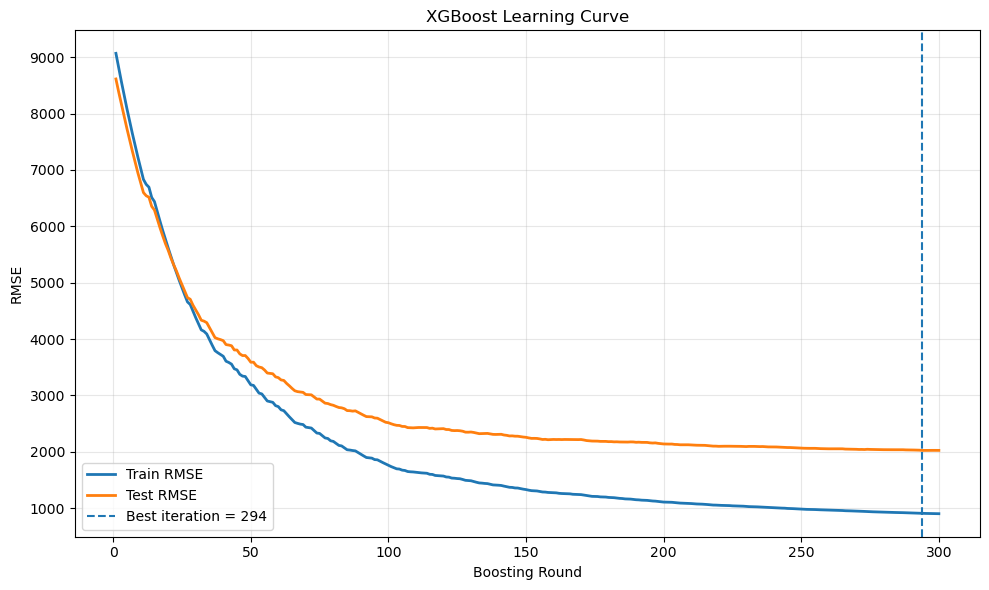

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb

if best_params_xgb is None:
    print("WARNING: best_params_xgb is None — falling back to conservative defaults.")
    best_params_xgb = {
        "max_depth": 4,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }

print("Hyperparameters for final fit:")
for k, v in best_params_xgb.items():
    print(f"  {k:<22} {v}")
print()

xgb_final = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective="reg:squarederror",
    early_stopping_rounds=20,
    eval_metric="rmse",
    random_state=42,
    verbosity=0,
    enable_categorical=True,   # required for industry_group_cat
    tree_method="hist",        # required for categorical feature support
    **best_params_xgb,
)

xgb_final.fit(
    X_train_xgb,
    y_train_xgb,
    eval_set=[
        (X_train_xgb, y_train_xgb),
        (X_test_xgb, y_test_xgb)
    ],
    verbose=False,
)

n_trees = xgb_final.best_iteration + 1
print(f"Optimal trees (early stopping) : {n_trees}")

xgb_pred_arr = pd.Series(
    xgb_final.predict(X_test_xgb),
    index=X_test_xgb.index
)

xgb_rmse = np.sqrt(mean_squared_error(y_test_xgb, xgb_pred_arr))
xgb_mae  = mean_absolute_error(y_test_xgb, xgb_pred_arr)
print(f"XGBoost RMSE (per state-month) : {xgb_rmse:,.1f}")
print(f"XGBoost MAE  (per state-month) : {xgb_mae:,.1f}")

# ── Learning curve ──────────────────────────────────────────────────────────
results = xgb_final.evals_result()

train_rmse = results["validation_0"]["rmse"]
test_rmse  = results["validation_1"]["rmse"]
rounds = np.arange(1, len(train_rmse) + 1)

plt.figure(figsize=(10, 6))
plt.plot(rounds, train_rmse, label="Train RMSE", linewidth=2)
plt.plot(rounds, test_rmse,  label="Test RMSE", linewidth=2)
plt.axvline(n_trees, linestyle="--", linewidth=1.5, label=f"Best iteration = {n_trees}")

plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("XGBoost Learning Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## XGBoost Test Set Forecast Plot

Aggregate and per-state views of the XGBoost forecast. Both the **in-sample fitted line** (training period) and the **out-of-sample forecast** (test period) are shown for a complete picture of model fit across the full sample.


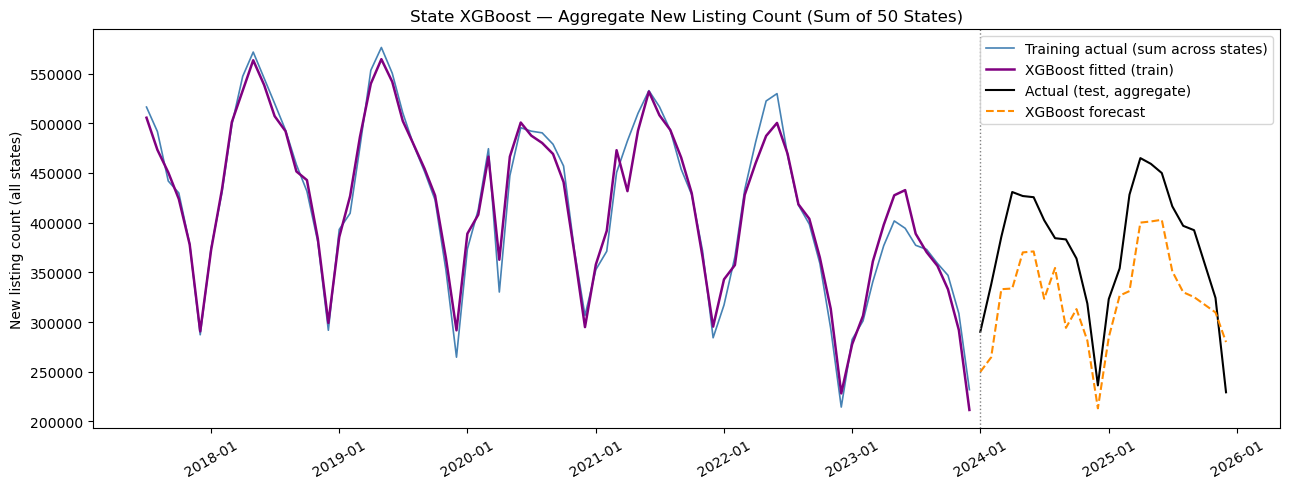

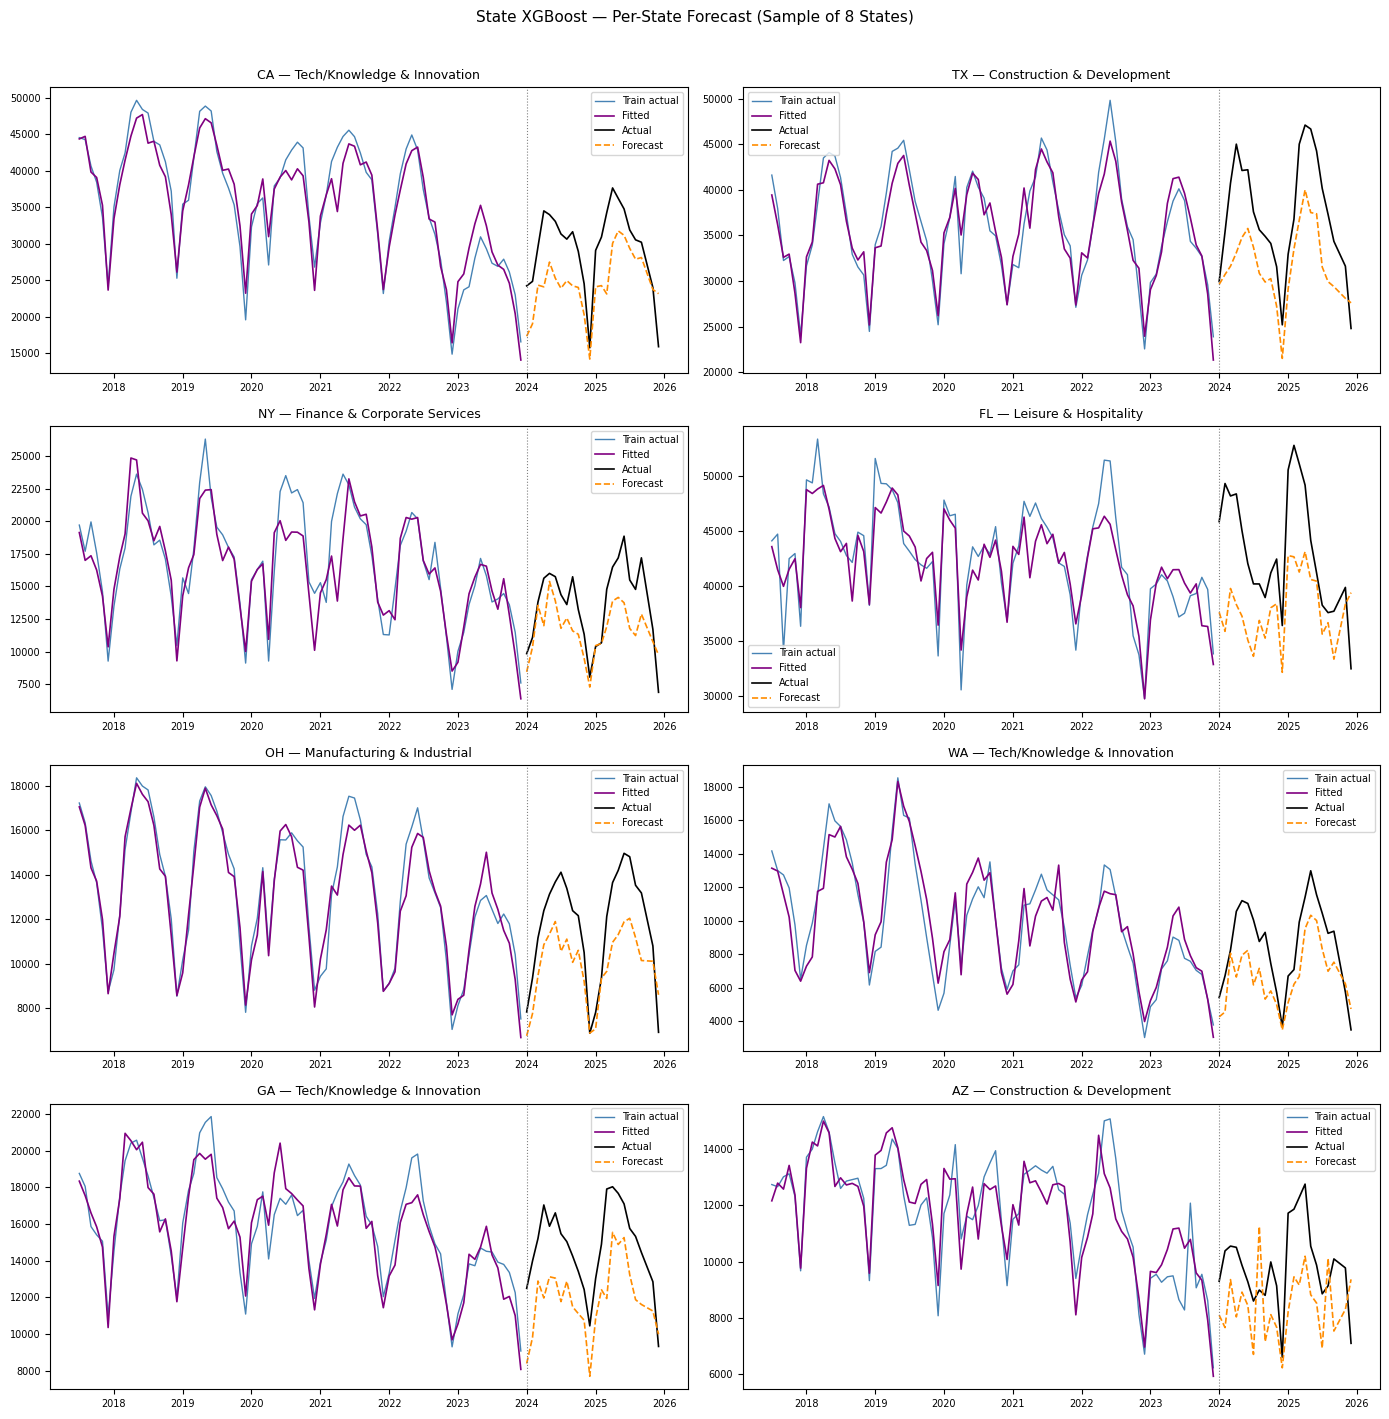

In [19]:
# ── Reconstruct test and train dataframes with predictions ───────────────────
test_feat_df  = feat_full[feat_full["time"] >= split_ts].copy()
test_feat_df["xgb_pred"] = xgb_pred_arr.values

train_feat_df = feat_full[feat_full["time"] < split_ts].copy()
train_feat_df["xgb_fitted"] = xgb_final.predict(X_train_xgb)

# ── Aggregate plot — with fitted line ─────────────────────────────────────────
agg_train_y   = train_feat_df.groupby("time")["Y"].sum()
agg_train_fit = train_feat_df.groupby("time")["xgb_fitted"].sum()
agg_test_y    = test_feat_df.groupby("time")["Y"].sum()
agg_test_pred = test_feat_df.groupby("time")["xgb_pred"].sum()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(agg_train_y.index, agg_train_y.values,
        color="steelblue", linewidth=1.2, label="Training actual (sum across states)")
ax.plot(agg_train_fit.index, agg_train_fit.values,
        color="purple", linewidth=1.8, linestyle="-", label="XGBoost fitted (train)")
ax.plot(agg_test_y.index, agg_test_y.values,
        color="black", linewidth=1.5, label="Actual (test, aggregate)")
ax.plot(agg_test_pred.index, agg_test_pred.values,
        color="darkorange", linewidth=1.5, linestyle="--", label="XGBoost forecast")
ax.axvline(pd.Timestamp(split_date), color="gray", linestyle=":", linewidth=1)
ax.set_title("State XGBoost — Aggregate New Listing Count (Sum of 50 States)")
ax.set_ylabel("New listing count (all states)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("state_xgboost_forecast_aggregate.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Per-state sample plot — with fitted line ──────────────────────────────────
sample_states = ["CA", "TX", "NY", "FL", "OH", "WA", "GA", "AZ"]
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, st in zip(axes, sample_states):
    tr = train_feat_df[train_feat_df["state_abbr"] == st]
    te = test_feat_df[test_feat_df["state_abbr"] == st]
    ax.plot(tr["time"], tr["Y"],
            color="steelblue", linewidth=1.0, label="Train actual")
    ax.plot(tr["time"], tr["xgb_fitted"],
            color="purple", linewidth=1.2, linestyle="-", label="Fitted")
    ax.plot(te["time"], te["Y"],
            color="black", linewidth=1.2, label="Actual")
    ax.plot(te["time"], te["xgb_pred"],
            color="darkorange", linewidth=1.2, linestyle="--", label="Forecast")
    ax.axvline(pd.Timestamp(split_date), color="gray", linestyle=":", linewidth=0.8)
    ig = INDUSTRY_GROUPS[st]
    ax.set_title(f"{st} — {ig}", fontsize=9)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.suptitle("State XGBoost — Per-State Forecast (Sample of 8 States)", y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig("state_xgboost_forecast_sample_states.png", dpi=120, bbox_inches="tight")
plt.show()

## SHAP Interpretation

Compute SHAP values on the **test set** to interpret the XGBoost model:

- **SHAP bar plot**: feature importance ranked by mean absolute SHAP value — `industry_group_cat` will appear as a single feature representing the combined industry group effect
- **SHAP beeswarm plot**: direction and magnitude of each feature's effect
- **SHAP dependence plot for `dL_c`**: lock-in effect coloured by `U_c` — shows unemployment interaction discovered by the tree
- **SHAP dependence plot for `H_c`**: HPI level effect — direction confirms equity-unlocking vs affordability constraint
- **SHAP interaction values** between `dL_c` and `industry_group_cat`: recovers the industry-specific lock-in differential nonparametrically, replacing the explicit `LxD_k` columns from SARIMAX

With ~1,100 test state-month rows (22 months × 50 states), SHAP patterns are stable and interpretable.


Computing SHAP values (this may take a few minutes)...
SHAP values shape            : (1150, 6)
Base value (expected output) : 6,680.5

SHAP feature importance (all features):
           feature  mean_abs_shap
           Y_lag12    4455.148408
               H_c     466.430863
industry_group_cat     265.514722
              dL_c     233.111693
                dS     205.819449
               U_c      47.609916



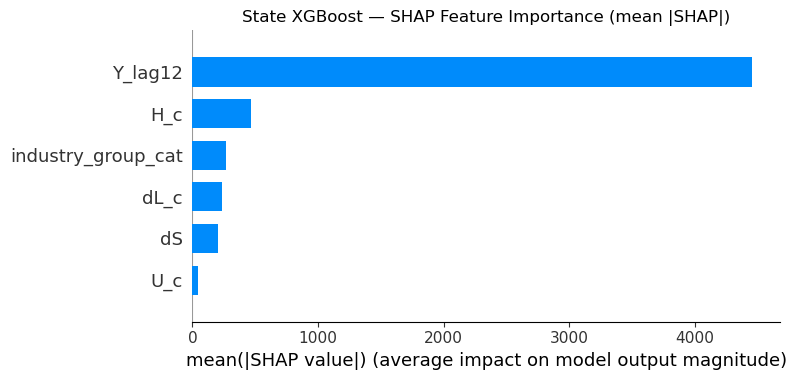

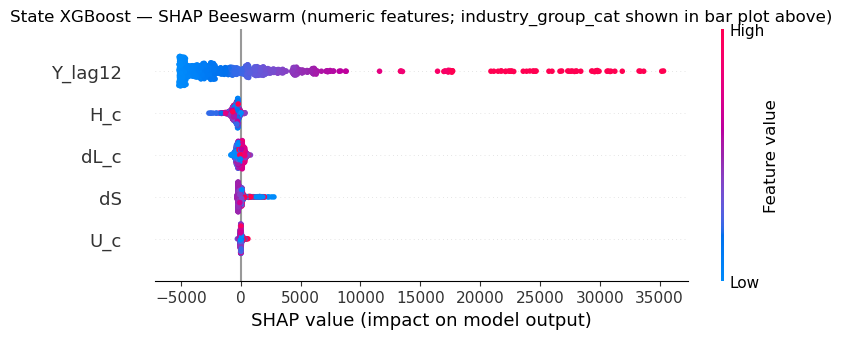

In [27]:
# ── SHAP explainer ────────────────────────────────────────────────────────────
# shap.TreeExplainer fails due to a base_score serialisation incompatibility
# between newer XGBoost and older SHAP versions. We use shap.Explainer with
# a custom predict wrapper that accepts the full feature DataFrame (including
# the Categorical column) and passes it directly to XGBoost.
#
# The key requirement: industry_group_cat must remain pandas Categorical —
# NOT converted to integer codes — so XGBoost sees the same dtype as training.
print("Computing SHAP values (this may take a few minutes)...")

# ── Separate numeric and categorical feature indices ──────────────────────────
numeric_feature_cols = [c for c in feature_cols if c != "industry_group_cat"]
ig_idx               = feature_cols.index("industry_group_cat")
numeric_idx          = [feature_cols.index(c) for c in numeric_feature_cols]

# ── Predict wrapper: keeps Categorical dtype intact ───────────────────────────
def predict_fn(X):
    """
    Accepts a numpy array from SHAP's masker, reconstructs a DataFrame with
    the correct dtypes (including Categorical for industry_group_cat), and
    calls xgb_final.predict. This is necessary because SHAP's masker converts
    inputs to numpy arrays internally, stripping the Categorical dtype.
    """
    df = pd.DataFrame(X, columns=feature_cols)
    df["industry_group_cat"] = pd.Categorical(
        df["industry_group_cat"].astype(int).map(
            dict(enumerate([REFERENCE_GROUP] + NON_REF_GROUPS))
        ),
        categories=[REFERENCE_GROUP] + NON_REF_GROUPS,
    )
    # Restore numeric dtypes for other columns
    for col in numeric_feature_cols:
        df[col] = df[col].astype(float)
    return xgb_final.predict(df)

# ── Encode categorical as integer for SHAP's masker input ────────────────────
# SHAP's masker needs a numeric background array — encode the category as its
# integer position; predict_fn reconstructs the Categorical on the way out.
def encode_for_shap(df):
    out = df.copy()
    out["industry_group_cat"] = out["industry_group_cat"].cat.codes.astype(float)
    return out

X_train_encoded = encode_for_shap(X_train_xgb)
X_test_encoded  = encode_for_shap(X_test_xgb)

# Background sample for the masker (200 rows)
bg_sample = X_train_encoded.sample(200, random_state=42)

explainer   = shap.Explainer(predict_fn, bg_sample)
shap_expl   = explainer(X_test_encoded)
shap_values = shap_expl.values

# Full SHAP DataFrame for directional consistency check
shap_df_xgb = pd.DataFrame(shap_values, columns=feature_cols, index=X_test_xgb.index)

base_val = float(np.mean(shap_expl.base_values))
print(f"SHAP values shape            : {shap_values.shape}")
print(f"Base value (expected output) : {base_val:,.1f}")
print()

# ── Global importance table ───────────────────────────────────────────────────
shap_imp = (
    pd.DataFrame({
        "feature"      : feature_cols,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
print("SHAP feature importance (all features):")
print(shap_imp.to_string(index=False))
print()

# ── Summary bar plot — ALL features including industry_group_cat ──────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    feature_names=feature_cols,   # names only — no data matrix required
    plot_type="bar",
    max_display=20,
    show=False,
)
plt.title("State XGBoost — SHAP Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig("state_shap_summary_bar.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Beeswarm plot — numeric features only (Categorical cannot be coloured) ────
# industry_group_cat SHAP values are shown in the bar plot above.
# The beeswarm colour scale requires a numeric feature value per observation
# which a Categorical column cannot provide — so it is excluded here and
# interpreted separately via the industry group mean SHAP bar chart below.
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_numeric,
    X_test_numeric,
    max_display=20,
    show=False,
)
plt.title("State XGBoost — SHAP Beeswarm (numeric features; "
          "industry_group_cat shown in bar plot above)")
plt.tight_layout()
plt.savefig("state_shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

Computing SHAP interaction values for dL_c × industry_group_cat...

Mean SHAP interaction (dL_c × industry_group) by group:
  Negative = lock-in effect strengthened relative to model average
  Positive = lock-in effect weakened relative to model average

                               mean    std  count
industry_group                                   
Construction & Development   -12.85  40.48     92
Leisure & Hospitality         -8.53  33.35     92
Tech/Knowledge & Innovation   -6.17  46.77    161
Finance & Corporate Services   0.03  25.17    184
Manufacturing & Industrial     0.95  12.71    299
Energy/Resource-based          6.88  32.14    322


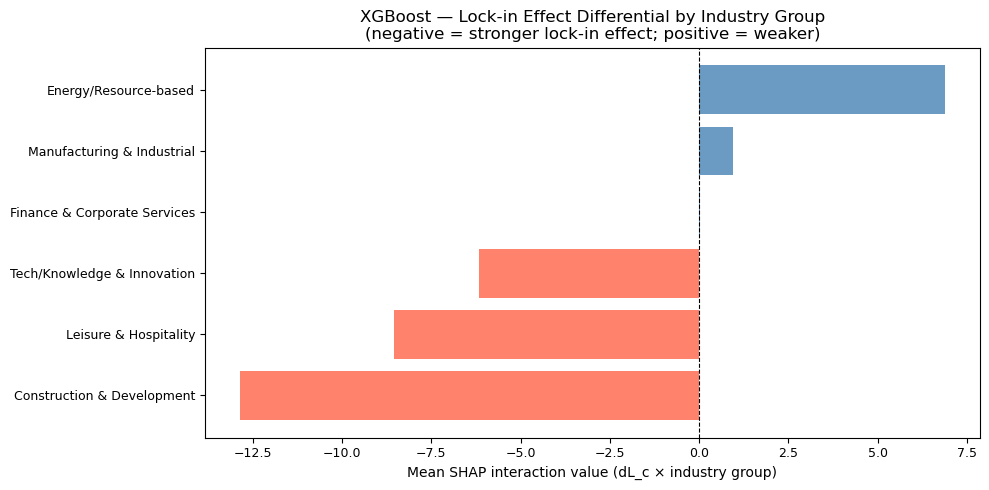

In [29]:
# ── SHAP interaction: dL_c × industry_group_cat ──────────────────────────────
print("Computing SHAP interaction values for dL_c × industry_group_cat...")

import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

feature_cols = list(X_test_xgb.columns)

booster = xgb_final.get_booster()
dm_test = xgb.DMatrix(X_test_xgb, enable_categorical=True)

# Native XGBoost SHAP interaction values
# Output shape: (n_obs, n_features + 1, n_features + 1)
# Last row/col is the bias term
shap_inter_full = booster.predict(dm_test, pred_interactions=True)

# Drop bias row/column
shap_inter = shap_inter_full[:, :-1, :-1]

dLc_idx = feature_cols.index("dL_c")
ig_idx  = feature_cols.index("industry_group_cat")

inter_vals = shap_inter[:, dLc_idx, ig_idx]

# Align interaction rows with X_test_xgb rows
inter_df = pd.DataFrame({
    "inter_dLc_ig": inter_vals,
    "industry_group": X_test_xgb["industry_group_cat"].astype(str).values
})

print()
print("Mean SHAP interaction (dL_c × industry_group) by group:")
print("  Negative = lock-in effect strengthened relative to model average")
print("  Positive = lock-in effect weakened relative to model average")
print()

inter_by_group = (
    inter_df.groupby("industry_group")["inter_dLc_ig"]
    .agg(["mean", "std", "count"])
    .round(2)
    .sort_values("mean")
)

print(inter_by_group.to_string())

# ── Bar chart of mean interaction by group ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["tomato" if v < 0 else "steelblue" for v in inter_by_group["mean"]]

ax.barh(inter_by_group.index.astype(str), inter_by_group["mean"], color=colors, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean SHAP interaction value (dL_c × industry group)")
ax.set_title(
    "XGBoost — Lock-in Effect Differential by Industry Group\n"
    "(negative = stronger lock-in effect; positive = weaker)"
)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("state_shap_industry_interaction.png", dpi=120, bbox_inches="tight")
plt.show()

## Model Performance Comparison

Compare SARIMAX and XGBoost on the **same test set** at the state-month level and at the aggregate (national sum) level. RMSE and MAE are computed per state-month row for consistency across the two models.


Model performance on common test set (per state-month):
           RMSE     MAE
SARIMAX  8246.0  4736.6
XGBoost  2033.3  1237.1

Observations in common test window : 1,100
Common window start : 2024-02
Common window end   : 2025-12


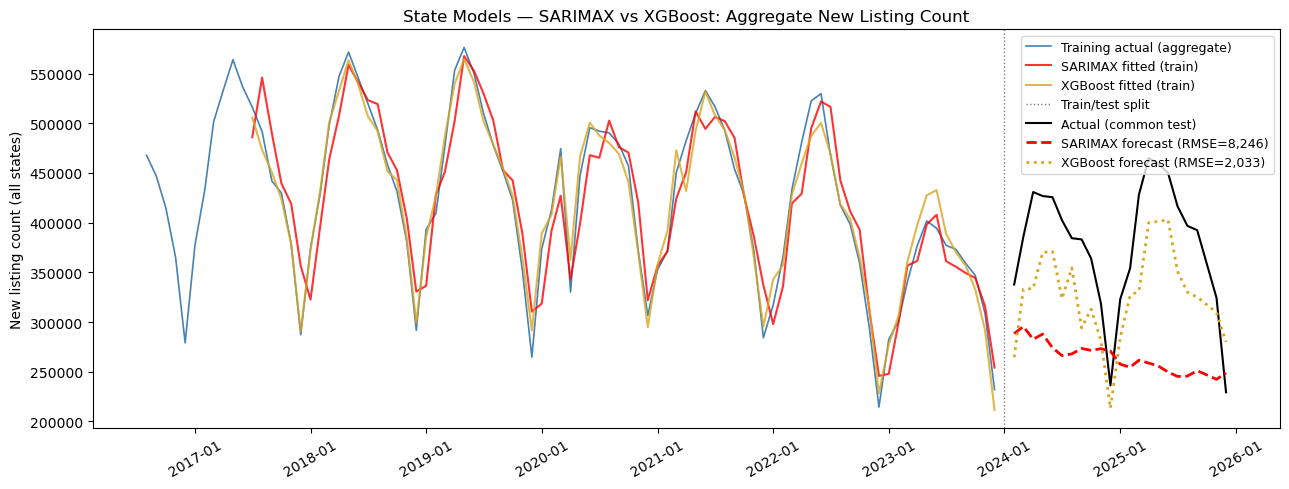

In [31]:
# ── Align predictions to common test observations ─────────────────────────────
sarimax_test_aligned = test_exog_df[["time", "state_abbr", "Y", "sarimax_pred"]].copy()
xgb_test_aligned     = test_feat_df[["time", "state_abbr", "Y", "xgb_pred"]].copy()

common = sarimax_test_aligned.merge(
    xgb_test_aligned[["time", "state_abbr", "xgb_pred"]],
    on=["time", "state_abbr"], how="inner"
)

sarimax_rmse_c = np.sqrt(mean_squared_error(common["Y"], common["sarimax_pred"]))
sarimax_mae_c  = mean_absolute_error(common["Y"], common["sarimax_pred"])
xgb_rmse_c     = np.sqrt(mean_squared_error(common["Y"], common["xgb_pred"]))
xgb_mae_c      = mean_absolute_error(common["Y"], common["xgb_pred"])

comparison = pd.DataFrame({
    "RMSE": [sarimax_rmse_c, xgb_rmse_c],
    "MAE" : [sarimax_mae_c,  xgb_mae_c],
}, index=["SARIMAX", "XGBoost"]).round(1)

print("Model performance on common test set (per state-month):")
print(comparison.to_string())
print()
print(f"Observations in common test window : {len(common):,}")
print(f"Common window start : {common['time'].min().strftime('%Y-%m')}")
print(f"Common window end   : {common['time'].max().strftime('%Y-%m')}")

# ── Aggregate fitted lines from training dataframes ───────────────────────────
# Align both fitted series to the common training index so the plot is clean
# even if the two models start at slightly different rows after dropna.
agg_train_actual   = train_exog_df.groupby("time")["Y"].sum()
agg_sarimax_fitted = train_exog_df.groupby("time")["sarimax_fitted"].sum()
agg_xgb_fitted     = train_feat_df.groupby("time")["xgb_fitted"].sum()

# Common training index: only months present in both fitted series
common_train_idx   = agg_sarimax_fitted.index.intersection(agg_xgb_fitted.index)

# ── Aggregate test predictions ────────────────────────────────────────────────
agg_actual  = common.groupby("time")["Y"].sum()
agg_sarimax = common.groupby("time")["sarimax_pred"].sum()
agg_xgb     = common.groupby("time")["xgb_pred"].sum()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

# Training actual
ax.plot(agg_train_actual.index, agg_train_actual.values,
        color="steelblue", linewidth=1.2, label="Training actual (aggregate)")

# Fitted lines — training period
ax.plot(agg_sarimax_fitted.loc[common_train_idx].index,
        agg_sarimax_fitted.loc[common_train_idx].values,
        color="red", linewidth=1.5, linestyle="-",
        label="SARIMAX fitted (train)", alpha=0.8)
ax.plot(agg_xgb_fitted.loc[common_train_idx].index,
        agg_xgb_fitted.loc[common_train_idx].values,
        color="goldenrod", linewidth=1.5, linestyle="-",
        label="XGBoost fitted (train)", alpha=0.8)

# Train/test split line
ax.axvline(pd.Timestamp(split_date), color="gray", linestyle=":", linewidth=1,
           label="Train/test split")

# Test actual
ax.plot(agg_actual.index, agg_actual.values,
        color="black", linewidth=1.5, label="Actual (common test)")

# Test forecasts
ax.plot(agg_sarimax.index, agg_sarimax.values,
        color="red", linewidth=2.0, linestyle="--",
        label=f"SARIMAX forecast (RMSE={sarimax_rmse_c:,.0f})")
ax.plot(agg_xgb.index, agg_xgb.values,
        color="goldenrod", linewidth=2.0, linestyle=":",
        label=f"XGBoost forecast (RMSE={xgb_rmse_c:,.0f})")

ax.set_title("State Models — SARIMAX vs XGBoost: Aggregate New Listing Count")
ax.set_ylabel("New listing count (all states)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("state_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## Directional Consistency Check

Compare the direction of each effect across SARIMAX and XGBoost, following the Tier 3 evaluation framework in Plan A.

- **SARIMAX**: sign of the coefficient $\hat{\beta}_k$ or $\hat{\lambda}_k$
- **XGBoost**: sign of the mean SHAP value for the corresponding feature across the test set

Features checked: $\widetilde{\Delta L}_t$ (`dL_c`), $\tilde{U}_{it}$ (`U_c`), $\tilde{H}_{it}$ (`H_c`), $\Delta S_{it}$ (`dS`), `LxU` (SARIMAX only), and industry group interactions (SARIMAX $\hat{\lambda}_k$ vs XGBoost SHAP interaction values).

Agreement constitutes convergent evidence. Disagreements should be investigated via SHAP dependence plots before reporting.


In [32]:
# ── Main economic features ───────────────────────────────────────────────────
features_to_check = ["dL_c", "U_c", "H_c", "dS", "LxU"]

feature_labels = {
    "dL_c": "Centered change in lock-in (dL_c)",
    "U_c" : "Centered unemployment (U_c)",
    "H_c" : "Centered HPI levels (H_c)",
    "dS"  : "Change in permits (dS)",
    "LxU" : "Lock-in × Unemployment (LxU) — SARIMAX only",
}

print("=" * 72)
print("DIRECTIONAL CONSISTENCY CHECK — STATE MODELS")
print("=" * 72)
print()
print("── Main economic features ──────────────────────────────────────────────")
print()

for feat in features_to_check:
    label = feature_labels.get(feat, feat)

    if feat in coef_df.index:
        beta  = coef_df.loc[feat, "coefficient"]
        pval  = coef_df.loc[feat, "p_value"]
        ci_lo = coef_df.loc[feat, "ci_lower"]
        ci_hi = coef_df.loc[feat, "ci_upper"]
    else:
        beta, pval, ci_lo, ci_hi = np.nan, np.nan, np.nan, np.nan

    if feat in shap_df_xgb.columns:
        shap_mean = shap_df_xgb[feat].mean()
    else:
        shap_mean = np.nan

    if np.isfinite(beta) and np.isfinite(shap_mean):
        agreement = "YES ✓" if (beta < 0) == (shap_mean < 0) else "NO  ✗"
    elif np.isfinite(beta) and not np.isfinite(shap_mean):
        agreement = "SARIMAX only"
    else:
        agreement = "N/A"

    shap_sign = (
        "negative (↓ listings)" if np.isfinite(shap_mean) and shap_mean < 0 else
        "positive (↑ listings)" if np.isfinite(shap_mean) else "N/A (not in XGBoost)"
    )

    print(f"{label}:")
    if np.isfinite(beta):
        print(f"  SARIMAX coef       = {beta:.4f}  (p={pval:.4f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}])")
    else:
        print(f"  SARIMAX coef       = not available")
    print(f"  XGBoost mean SHAP  = {shap_mean:.2f}  → {shap_sign}")
    print(f"  Direction match    = {agreement}")
    print()

# ── Industry group interaction comparison ─────────────────────────────────────
print("── Industry group lock-in interactions ─────────────────────────────────")
print()
print("  SARIMAX λ_k (LxD_k) vs XGBoost mean SHAP interaction (dL_c × industry)")
print()

for g in NON_REF_GROUPS:
    lk, lp = get_coef(f"LxD_{g}")
    # XGBoost: mean interaction from inter_by_group computed in SHAP cell
    if g in inter_by_group.index:
        xgb_inter = inter_by_group.loc[g, "mean"]
    else:
        xgb_inter = np.nan

    if np.isfinite(lk) and np.isfinite(xgb_inter):
        agreement = "YES ✓" if (lk < 0) == (xgb_inter < 0) else "NO  ✗"
    else:
        agreement = "N/A"

    print(f"  {g}:")
    if np.isfinite(lk):
        print(f"    SARIMAX λ_k     = {lk:.4f}  (p={lp:.4f})")
    else:
        print(f"    SARIMAX λ_k     = not available")
    print(f"    XGBoost inter   = {xgb_inter:.4f}" if np.isfinite(xgb_inter) else "    XGBoost inter   = N/A")
    print(f"    Direction match = {agreement}")
    print()

print("=" * 72)

DIRECTIONAL CONSISTENCY CHECK — STATE MODELS

── Main economic features ──────────────────────────────────────────────

Centered change in lock-in (dL_c):
  SARIMAX coef       = -308.2433  (p=0.7584, 95% CI [-2272.7795, 1656.2929])
  XGBoost mean SHAP  = -61.40  → negative (↓ listings)
  Direction match    = YES ✓

Centered unemployment (U_c):
  SARIMAX coef       = -358.6676  (p=0.0000, 95% CI [-400.2624, -317.0729])
  XGBoost mean SHAP  = 30.30  → positive (↑ listings)
  Direction match    = NO  ✗

Centered HPI levels (H_c):
  SARIMAX coef       = -17.1626  (p=0.0000, 95% CI [-17.7456, -16.5797])
  XGBoost mean SHAP  = -458.36  → negative (↓ listings)
  Direction match    = YES ✓

Change in permits (dS):
  SARIMAX coef       = 59.9584  (p=0.0005, 95% CI [26.3852, 93.5317])
  XGBoost mean SHAP  = 26.13  → positive (↑ listings)
  Direction match    = YES ✓

Lock-in × Unemployment (LxU) — SARIMAX only:
  SARIMAX coef       = -497.3695  (p=0.0001, 95% CI [-746.3571, -248.3820])
  XGBoost

## Performance by Industry Group

Break down test RMSE and MAE by industry group to assess whether either model performs systematically better or worse for specific state clusters.


Per-industry-group model performance on common test set:
              industry_group  n_states  SARIMAX_RMSE  SARIMAX_MAE  XGBoost_RMSE  XGBoost_MAE XGB_better_RMSE
       Energy/Resource-based        14        2380.1       1830.8         511.2        382.4               ✓
  Manufacturing & Industrial        13        3855.9       3167.8        1330.6       1049.2               ✓
Finance & Corporate Services         8        5964.0       4884.2        1820.2       1331.6               ✓
 Tech/Knowledge & Innovation         7        8396.5       5318.6        2988.0       2276.0               ✓
       Leisure & Hospitality         4       18482.6      13491.2        3356.7       1874.6               ✓
  Construction & Development         4       15674.5       9937.1        3390.1       2195.0               ✓


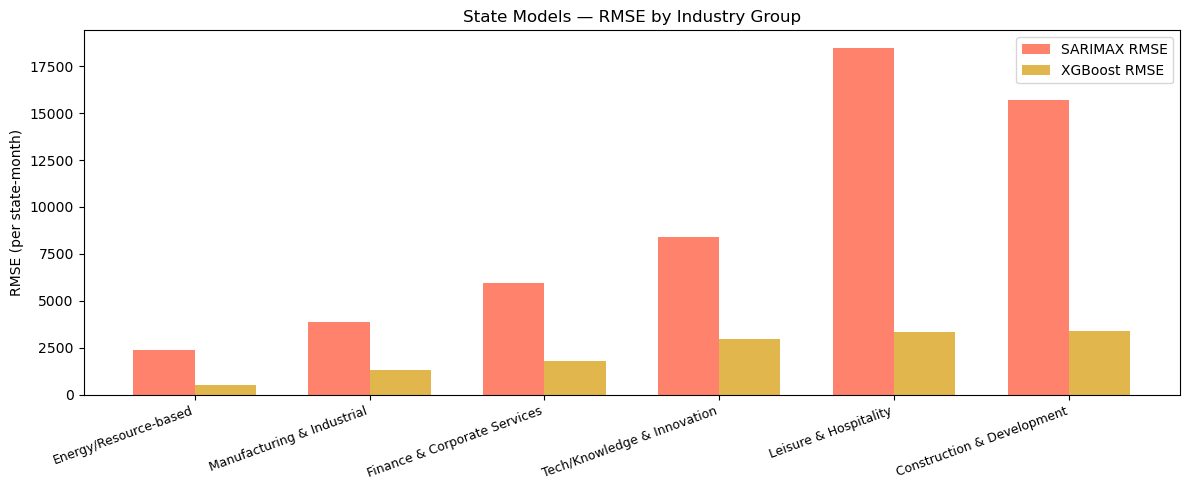

In [33]:
# Attach industry group to common test frame
ig_map = pd.Series(INDUSTRY_GROUPS, name="industry_group")
common["industry_group"] = common["state_abbr"].map(ig_map)

group_perf = []
for ig, grp in common.groupby("industry_group"):
    s_rmse = np.sqrt(mean_squared_error(grp["Y"], grp["sarimax_pred"]))
    s_mae  = mean_absolute_error(grp["Y"], grp["sarimax_pred"])
    x_rmse = np.sqrt(mean_squared_error(grp["Y"], grp["xgb_pred"]))
    x_mae  = mean_absolute_error(grp["Y"], grp["xgb_pred"])
    group_perf.append({
        "industry_group"   : ig,
        "n_states"         : grp["state_abbr"].nunique(),
        "SARIMAX_RMSE"     : round(s_rmse, 1),
        "SARIMAX_MAE"      : round(s_mae,  1),
        "XGBoost_RMSE"     : round(x_rmse, 1),
        "XGBoost_MAE"      : round(x_mae,  1),
        "XGB_better_RMSE"  : "✓" if x_rmse < s_rmse else "✗",
    })

perf_df = pd.DataFrame(group_perf).sort_values("XGBoost_RMSE")
print("Per-industry-group model performance on common test set:")
print(perf_df.to_string(index=False))

# ── Bar chart ──────────────────────────────────────────────────────────────────
x_pos = np.arange(len(perf_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x_pos - width/2, perf_df["SARIMAX_RMSE"], width,
       label="SARIMAX RMSE", color="tomato", alpha=0.8)
ax.bar(x_pos + width/2, perf_df["XGBoost_RMSE"], width,
       label="XGBoost RMSE", color="goldenrod", alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(perf_df["industry_group"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("RMSE (per state-month)")
ax.set_title("State Models — RMSE by Industry Group")
ax.legend()
plt.tight_layout()
plt.savefig("state_rmse_by_industry_group.png", dpi=120, bbox_inches="tight")
plt.show()

## State Model — Key Conclusions

**Panel structure and industry identification**
- The pooled 50-state × 113-month panel provides 5,650 state-month observations, giving the industry interaction terms genuine cross-sectional identifying variation — states in different industry groups face the identical national $L_t$ simultaneously, so differential listing responses are attributable to industry structure
- Industry group dummies $D_{ki}$ in SARIMAX absorb baseline listing level heterogeneity; the $\lambda_k$ estimates therefore reflect differential lock-in responses net of level differences
- In XGBoost, the categorical `industry_group` feature achieves the same goal nonparametrically through tree splits

**HPI treatment**
- HPI enters as centered levels $\tilde{H}_{it} = H_{it} - \bar{H}_i$ in both models — not differenced — because step-interpolated quarterly data produces $\Delta H_{it} = 0$ for 2 out of every 3 months, which is a structurally broken series
- The sign of $\hat{\beta}_3$ (SARIMAX) and the SHAP dependence plot for `H_c` (XGBoost) together reveal whether above-average prices stimulate listings (equity-unlocking) or suppress them (affordability constraint)
- This is a limitation: the quarterly frequency means within-quarter price dynamics are not captured

**Lock-in effect ($\hat{\beta}_1$, `dL_c`)**
- See coefficient table above. Compare sign and significance to the national model result.

**Unemployment interaction ($\hat{\beta}_5$, `LxU` in SARIMAX; SHAP interaction in XGBoost)**
- The state-level test has richer variation (50 states with differing unemployment histories) and is a stronger test of the unemployment amplification hypothesis than the national model.

**Industry group interactions ($\hat{\lambda}_k$ in SARIMAX; SHAP interactions in XGBoost)**
- These are the primary novel contribution of the state model. Convergence between SARIMAX $\hat{\lambda}_k$ and XGBoost SHAP interaction values constitutes strong evidence of genuine industry heterogeneity in the lock-in mechanism.

**Data limitations to note**
- HPI is quarterly expanded to monthly — within-quarter price dynamics not captured; $\tilde{H}_{it}$ is constant across 3-month windows
- Permits data ends 2025-12; listing data clipped to match — no 2026 dynamics
- Pooled SARIMAX imposes a common ARIMA order across states with heterogeneous serial structures
- Non-normal residuals in SARIMAX (driven by COVID-period outliers and cross-sectional dependence) mean confidence intervals are approximate
